# Checking for gnomAD enrichments of benign variants and gene deletions among D&D genes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
import random

In [2]:
plt.rcParams['figure.dpi'] = 300

## Load gnomAD structural variant data

In [3]:
def parse_info_field(info_str):
    info = {}
    if info_str == ".":
        return info

    for entry in info_str.split(";"):
        if "=" in entry:
            k, v = entry.split("=", 1)
            info[k] = v
        else:
            info[entry] = True
    return info


def vcf_to_dataframe(vcf_path):
    rows = []

    with open(vcf_path, "r") as f:
        for line in f:
            if line.startswith("##"):
                continue

            if line.startswith("#CHROM"):
                header = line.strip().split("\t")
                sample_names = header[9:]
                continue

            fields = line.strip().split("\t")

            info = parse_info_field(fields[7])

            row = {
                "CHROM": fields[0],
                "POS": int(fields[1]),
                "ID": fields[2],
                "REF": fields[3],
                "ALT": fields[4],
                "QUAL": fields[5],
                "FILTER": fields[6],
            }

            # flatten INFO into columns
            row.update(info)

            rows.append(row)

    return pd.DataFrame(rows)

Number of unique genes with at least one rare deletion: 15522
Number of unique genes with at least 5 rare deletions: 4026


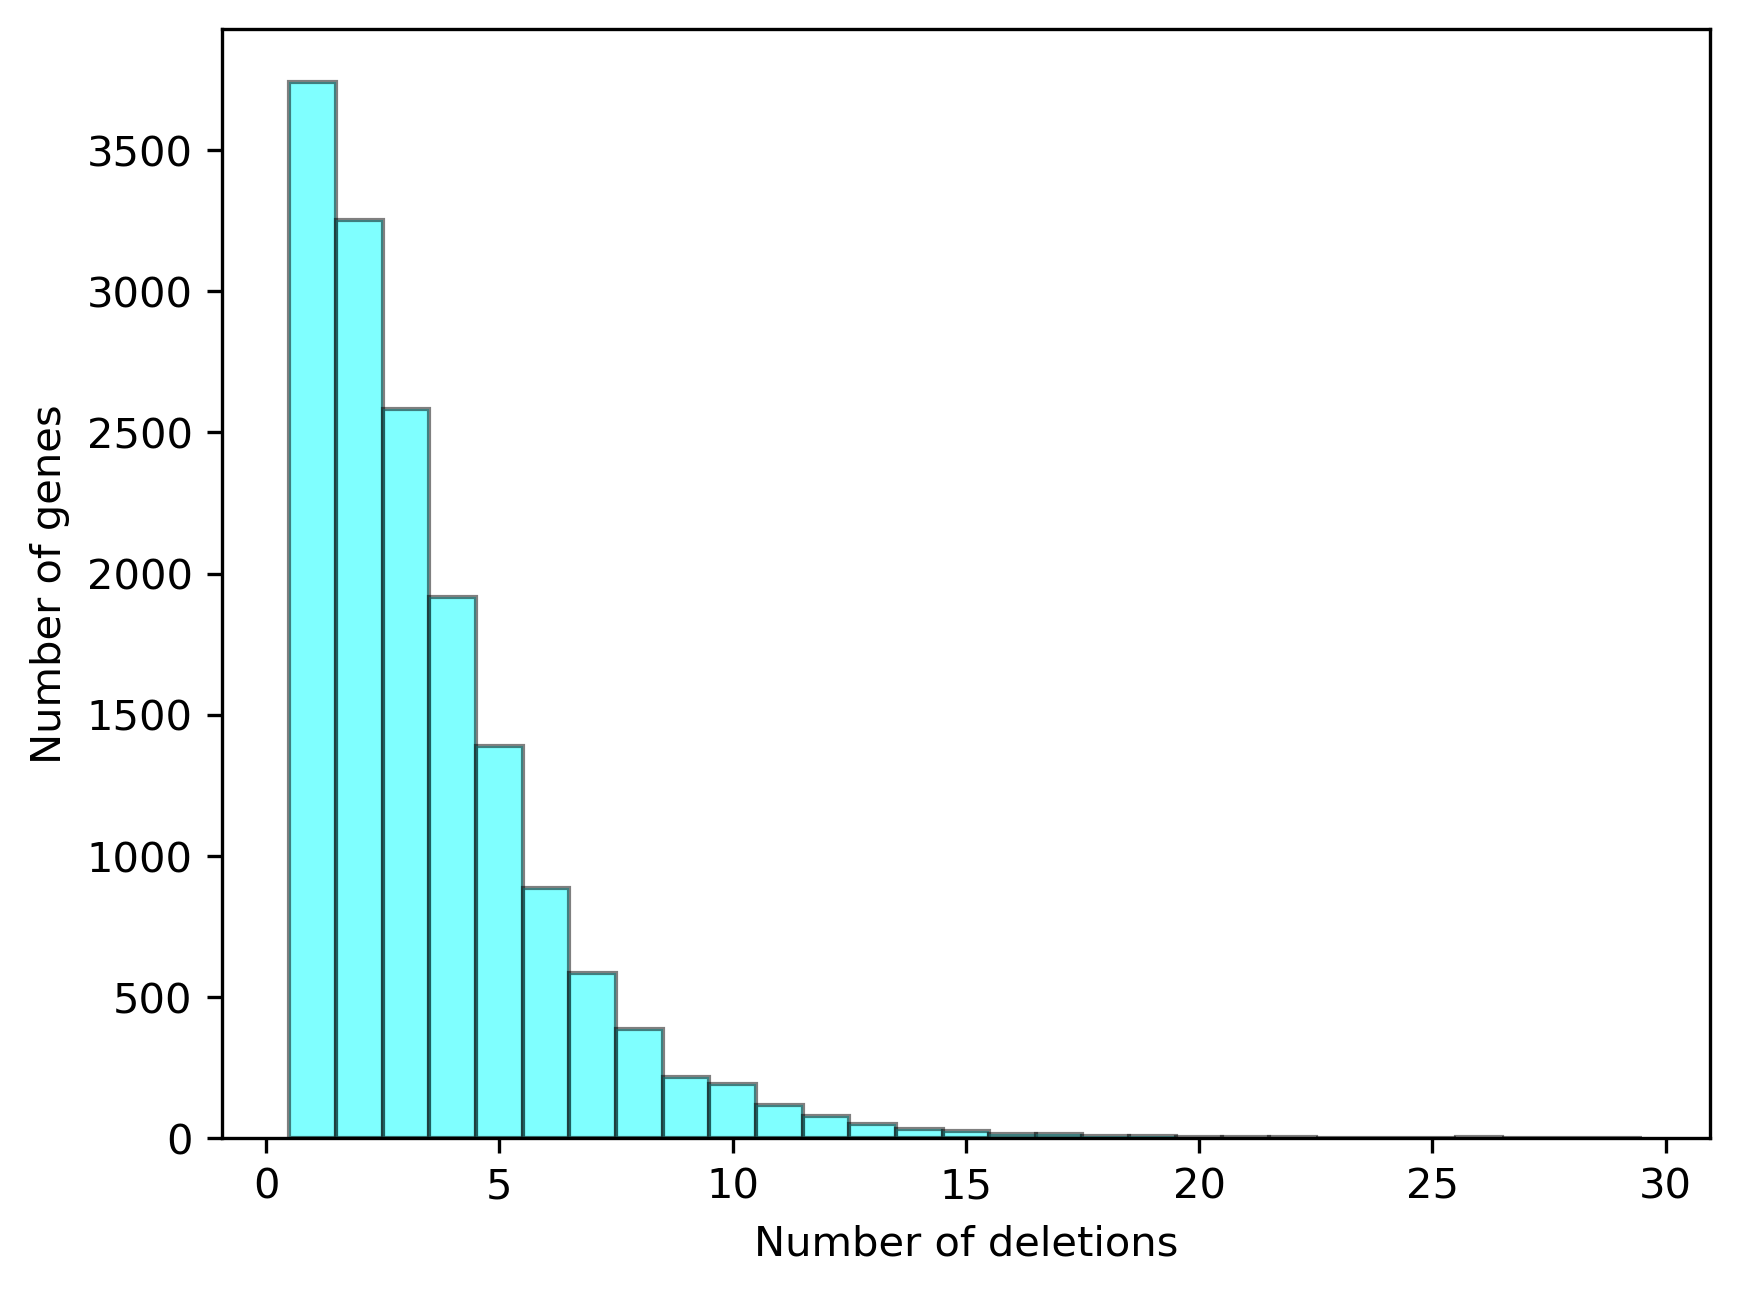

In [4]:
# load vcf file
df = vcf_to_dataframe("/wynton/home/capra/gramey02/ds_context_project/data/gnomAD/v4.1.1/gnomad.v4.1.cnv.all.vcf")
# filter to structural variants that pass quality control
pass_df = df[df['FILTER']=='PASS']
# filter columns
pass_df = pass_df[["CHROM","POS","ID","REF","ALT","QUAL","FILTER","END","SVLEN","SVTYPE",
             "POSMIN","POSMAX","ENDMIN","ENDMAX","Genes","N_EXN_VAR","N_INT_VAR"]]

# right now there can be multiple genes affected per structural var. expand these
# expand the genes affected by each deletion:
pass_df["Genes"] = pass_df["Genes"].fillna("").astype(str) # fill NAs
pass_expanded = pass_df.assign(Genes=pass_df["Genes"].str.split(",")).explode("Genes") # explode genes in the same row
pass_expanded["Genes"] = pass_expanded["Genes"].str.strip()

# filter to just deletions
dels_expanded = pass_expanded[pass_expanded['ALT']=='<DEL>']

# view distribution of number of rare deletions per gene
print(f"Number of unique genes with at least one rare deletion: {dels_expanded.Genes.nunique()}") # print number of unique genes deleted
gene_counts=pd.DataFrame(dels_expanded.Genes.value_counts()).reset_index()
gene_counts=gene_counts[~gene_counts['Genes'].isin(['None'])]
thresh=5
thresh_passing=gene_counts[gene_counts['count']>=thresh]
print(f"Number of unique genes with at least 5 rare deletions: {thresh_passing.Genes.nunique()}")
counts = gene_counts['count']
bins = np.arange(counts.min(), counts.max() + 2) - 0.5
plt.hist(gene_counts['count'],color='cyan',alpha=0.5,edgecolor='black',bins=bins)
plt.xlabel('Number of deletions')
plt.ylabel('Number of genes')
plt.show()

## Let's see if we can find heterozygosity information

In [5]:
# see if there's a way to determine heterozygosity of the Deletions
dels_expanded

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,END,SVLEN,SVTYPE,POSMIN,POSMAX,ENDMIN,ENDMAX,Genes,N_EXN_VAR,N_INT_VAR
0,chr1,925634,variant_is_80_2__DEL,N,<DEL>,.,PASS,931187,5553,DEL,925634,925634,930434,931187,SAMD11,3,4
1,chr1,925634,variant_is_80_3__DEL,N,<DEL>,.,PASS,935994,10360,DEL,925634,925634,935994,935994,SAMD11,4,5
4,chr1,925634,variant_is_80_4__DEL,N,<DEL>,.,PASS,968686,43052,DEL,925634,951903,939558,982191,KLHL17,40,36
4,chr1,925634,variant_is_80_4__DEL,N,<DEL>,.,PASS,968686,43052,DEL,925634,951903,939558,982191,NOC2L,40,36
4,chr1,925634,variant_is_80_4__DEL,N,<DEL>,.,PASS,968686,43052,DEL,925634,951903,939558,982191,SAMD11,40,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68692,chr22,50684488,variant_is_80_350208__DEL,N,<DEL>,.,PASS,50740457,55969,DEL,50674800,50694678,50731579,50740457,SHANK3,13,17
68695,chr22,50730624,variant_is_80_350252__DEL,N,<DEL>,.,PASS,50740457,9833,DEL,50730624,50730624,50740457,50740457,ACR,4,5
68695,chr22,50730624,variant_is_80_350252__DEL,N,<DEL>,.,PASS,50740457,9833,DEL,50730624,50730624,50740457,50740457,SHANK3,4,5
68697,chr22,50737293,variant_is_80_350256__DEL,N,<DEL>,.,PASS,50740457,3164,DEL,50731582,50737293,50740457,50740457,ACR,3,4


In [6]:
def parse_info_field(info_str):
    info = {}
    if info_str == ".":
        return info
    for entry in info_str.split(";"):
        if "=" in entry:
            k, v = entry.split("=", 1)
            info[k] = v
        else:
            info[entry] = True
    return info

# fields we specifically want as clean numeric columns, if present
ZYGOSITY_FIELDS = ["AC", "AN", "N_HOMREF", "N_HET", "N_HOMALT",
                    "FREQ_HOMREF", "FREQ_HET", "FREQ_HOMALT"]

def vcf_to_dataframe(vcf_path):
    rows = []
    with open(vcf_path, "r") as f:
        for line in f:
            if line.startswith("##"):
                continue
            if line.startswith("#CHROM"):
                header = line.strip().split("\t")
                sample_names = header[9:]
                continue
            fields = line.strip().split("\t")
            info = parse_info_field(fields[7])
            row = {
                "CHROM": fields[0],
                "POS": int(fields[1]),
                "ID": fields[2],
                "REF": fields[3],
                "ALT": fields[4],
                "QUAL": fields[5],
                "FILTER": fields[6],
            }
            # flatten all INFO fields as before
            row.update(info)

            # explicitly pull out zygosity fields as numeric columns
            # (falls back to None if the field isn't present in this VCF)
            for key in ZYGOSITY_FIELDS:
                val = info.get(key)
                if val is not None and val != ".":
                    try:
                        row[key] = float(val) if "." in val else int(val)
                    except ValueError:
                        row[key] = val
                else:
                    row[key] = None

            rows.append(row)
    return pd.DataFrame(rows)


def inspect_info_keys(vcf_path, n_lines=500):
    """Quick diagnostic: scan the first n_lines of records and report
    which INFO keys actually appear in this VCF -- useful for confirming
    whether N_HET/N_HOMALT/N_HOMREF exist before assuming they're missing."""
    seen_keys = set()
    n_checked = 0
    with open(vcf_path, "r") as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.strip().split("\t")
            info = parse_info_field(fields[7])
            seen_keys.update(info.keys())
            n_checked += 1
            if n_checked >= n_lines:
                break
    zygosity_related = sorted(k for k in seen_keys if
                               "HET" in k.upper() or "HOM" in k.upper() or k in ("AC", "AN"))
    print(f"Checked {n_checked} records.")
    print(f"Zygosity-related keys found: {zygosity_related}")
    return seen_keys

inspect_info_keys("/wynton/home/capra/gramey02/ds_context_project/data/gnomAD/v4.1.1/gnomad.v4.1.cnv.all.vcf")

Checked 500 records.
Zygosity-related keys found: []


{'END',
 'ENDMAX',
 'ENDMIN',
 'Genes',
 'N_EXN_VAR',
 'N_INT_VAR',
 'POSMAX',
 'POSMIN',
 'SC',
 'SC_XX',
 'SC_XY',
 'SC_afr',
 'SC_afr_XX',
 'SC_afr_XY',
 'SC_amr',
 'SC_amr_XX',
 'SC_amr_XY',
 'SC_asj',
 'SC_asj_XX',
 'SC_asj_XY',
 'SC_eas',
 'SC_eas_XX',
 'SC_eas_XY',
 'SC_fin',
 'SC_fin_XX',
 'SC_fin_XY',
 'SC_mid',
 'SC_mid_XX',
 'SC_mid_XY',
 'SC_nfe',
 'SC_nfe_XX',
 'SC_nfe_XY',
 'SC_remaining',
 'SC_remaining_XX',
 'SC_remaining_XY',
 'SC_sas',
 'SC_sas_XX',
 'SC_sas_XY',
 'SF',
 'SF_XX',
 'SF_XY',
 'SF_afr',
 'SF_afr_XX',
 'SF_afr_XY',
 'SF_amr',
 'SF_amr_XX',
 'SF_amr_XY',
 'SF_asj',
 'SF_asj_XX',
 'SF_asj_XY',
 'SF_eas',
 'SF_eas_XX',
 'SF_eas_XY',
 'SF_fin',
 'SF_fin_XX',
 'SF_fin_XY',
 'SF_mid',
 'SF_mid_XX',
 'SF_mid_XY',
 'SF_nfe',
 'SF_nfe_XX',
 'SF_nfe_XY',
 'SF_remaining',
 'SF_remaining_XX',
 'SF_remaining_XY',
 'SF_sas',
 'SF_sas_XX',
 'SF_sas_XY',
 'SN',
 'SN_XX',
 'SN_XY',
 'SN_afr',
 'SN_afr_XX',
 'SN_afr_XY',
 'SN_amr',
 'SN_amr_XX',
 'SN_amr_XY',
 'SN_asj',
 '

## Load D&D genes

In [7]:
dnd = pd.read_csv('/wynton/group/capra/projects/dnd_project_results/RUN_04_23_26/filtered_transcripts/filtered_exon_info.csv')
dnd_genes=set(dnd.hgnc_symbol)
print(len(dnd_genes))

593


/scratch/gramey02/ipykernel_3074375/2163340630.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dnd = pd.read_csv('/wynton/group/capra/projects/dnd_project_results/RUN_04_23_26/filtered_transcripts/filtered_exon_info.csv')


## Load gnomAD constraint file to curate a background gene set

In [8]:
constraint=pd.read_table('~/ds_context_project/data/gnomAD/v4.1.1/gnomad.v4.1.1.constraint_metrics.tsv.bgz', compression='gzip')
constraint

/scratch/gramey02/ipykernel_3074375/3289644112.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  constraint=pd.read_table('~/ds_context_project/data/gnomAD/v4.1.1/gnomad.v4.1.1.constraint_metrics.tsv.bgz', compression='gzip')


,gene,gene_id,transcript,canonical,mane_select,transcript_version,transcript_type,transcript_level,chromosome,start_position,...,lof.gen_anc_obs.sas,lof.gen_anc_exp.global,lof.gen_anc_exp.afr,lof.gen_anc_exp.amr,lof.gen_anc_exp.eas,lof.gen_anc_exp.nfe,lof.gen_anc_exp.sas,lof.pLI,lof.pNull,lof.pRec
0,A1BG,1,NM_130786.4,True,True,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,1,1,2,4,5,5,5,6,7,9,11]","[0.0,0.0,0.20272597201164205,0.632765277292762...","[0.0,0.0,0.2261337178814478,0.6491257059175704...","[0.0,0.0,0.21784151141329394,0.613465794278608...","[0.0,0.0,0.193446334557225,0.5059996264236443,...","[0.0,0.0,0.1548984822019654,0.4217657270975451...","[0.0,0.0,0.21335448007398916,0.588837314428807...",6.735200e-15,0.617080,0.38292
1,A1BG,ENSG00000121410,ENST00000263100,True,True,ENST00000263100.8,protein_coding,2.0,chr19,58345183.0,...,"[0,0,0,0,0,1,1,2,4,5,5,5,6,7,9,11]","[0.0,0.0,0.20272597201164205,0.632765277292762...","[0.0,0.0,0.2261337178814478,0.6491257059175704...","[0.0,0.0,0.21784151141329394,0.613465794278608...","[0.0,0.0,0.193446334557225,0.5059996264236443,...","[0.0,0.0,0.1548984822019654,0.4217657270975451...","[0.0,0.0,0.21335448007398916,0.588837314428807...",6.735200e-15,0.617080,0.38292
2,A1BG,ENSG00000121410,ENST00000600966,False,False,ENST00000600966.1,protein_coding,1.0,chr19,58350594.0,...,"[0,0,0,0,0,1,1,1,2,3,3,3,3,4,6,7]","[0.0,0.0,0.12745807628155528,0.394051215668179...","[0.0,0.0,0.142676777789689,0.4035080328682651,...","[0.0,0.0,0.1374727483539508,0.3820528904552813...","[0.0,0.0,0.12211621472306991,0.315481251396050...","[0.0,0.0,0.09793915936360853,0.263526385216192...","[0.0,0.0,0.13451258313791928,0.366914966171532...",2.162000e-06,0.123820,0.87618
3,A1CF,29974,NM_001198818.2,False,False,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,0,1,1,1,2,3,3,4,6,6,11]","[0.0,0.0,0.4313305595052932,1.343064140033738,...","[0.0,0.0,0.5002647995129001,1.37158202983447,2...","[0.0,0.0,0.47761619978821573,1.299785656697409...","[0.0,0.0,0.42627052646010655,1.087817287942070...","[0.0,0.0,0.3437403092409679,0.910440236626728,...","[0.0,0.0,0.4668153923166099,1.2569123678558363...",1.147200e-11,0.007810,0.99219
4,A1CF,29974,NM_001198819.2,False,False,NaN,NaN,NaN,NaN,NaN,...,"[0,0,0,0,0,0,1,2,2,3,4,4,5,7,7,12]","[0.0,0.0,0.43234413417655776,1.346069067255858...","[0.0,0.0,0.5013253631777227,1.3746295840481613...","[0.0,0.0,0.47864067330743876,1.302661462393719...","[0.0,0.0,0.42719186084964933,1.090273645053266...","[0.0,0.0,0.34449339724328465,0.912424644437811...","[0.0,0.0,0.46780419223724734,1.259700690753409...",1.141500e-12,0.014229,0.98577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221893,NaN,ENSG00000289491,ENST00000688509,True,False,ENST00000688509.1,protein_coding,2.0,chr16,30610211.0,...,"[0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1]","[0.0,0.0,0.002939661126150364,0.00904070564903...","[0.0,0.0,0.003208348253720337,0.00926590330764...","[0.0,0.0,0.0031067022490740993,0.0087626864689...","[0.0,0.0,0.002755903075091865,0.00720812738711...","[0.0,0.0,0.0022071523632052393,0.0059928992018...","[0.0,0.0,0.0030384002047708202,0.0083928528474...",4.302900e-02,0.290520,0.66645
221894,NaN,ENSG00000289503,ENST00000553426,True,False,ENST00000553426.2,nonsense_mediated_decay,2.0,chr14,62075340.0,...,"[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...",NaN,NaN,NaN
221895,NaN,ENSG00000289517,ENST00000617178,True,False,ENST00000617178.5,nonsense_mediated_decay,2.0,chr22,42583836.0,...,"[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[null,null,null,null,null,null,null,null,null,...","[nu

In [9]:
for x in list(constraint.columns):
    print(x)

gene
gene_id
transcript
canonical
mane_select
transcript_version
transcript_type
transcript_level
chromosome
start_position
end_position
cds_length
num_coding_exons
gene_quality_metrics.exome_prop_bp_AN90
gene_quality_metrics.exome_mean_AS_MQ
gene_quality_metrics.exome_prop_segdup
gene_quality_metrics.exome_prop_LCR
gene_flags
constraint_flags
syn.mu
syn.possible
syn.obs
syn.exp
syn.oe
syn.z_raw
syn.z_score
syn.oe_ci.lower
syn.oe_ci.upper
syn.gen_anc_obs.global
syn.gen_anc_obs.afr
syn.gen_anc_obs.amr
syn.gen_anc_obs.eas
syn.gen_anc_obs.nfe
syn.gen_anc_obs.sas
syn.gen_anc_exp.global
syn.gen_anc_exp.afr
syn.gen_anc_exp.amr
syn.gen_anc_exp.eas
syn.gen_anc_exp.nfe
syn.gen_anc_exp.sas
mis.mu
mis.possible
mis.obs
mis.exp
mis.oe
mis.z_raw
mis.z_score
mis.oe_ci.lower
mis.oe_ci.upper
mis.gen_anc_obs.global
mis.gen_anc_obs.afr
mis.gen_anc_obs.amr
mis.gen_anc_obs.eas
mis.gen_anc_obs.nfe
mis.gen_anc_obs.sas
mis.gen_anc_exp.global
mis.gen_anc_exp.afr
mis.gen_anc_exp.amr
mis.gen_anc_exp.eas
mis.gen_

In [10]:
# isolate the protein-coding genes with valid hgnc identifiers from this table

# all genes
universe=set(constraint[~constraint.gene.isna()]['gene'])
print(len(universe))

# protein-coding genes only
canonical=constraint[constraint['canonical']==True]
pc=canonical[canonical['transcript_type']=='protein_coding']
pc_universe=set(pc[~pc.gene.isna()]['gene'])
print(len(pc_universe))

19637
19055


In [11]:
# get observed number of deletions per gene
gene_list=[]
deletion_num_list=[]
for gene in dnd_genes:
    gene_list.append(gene)
    if gene in dels_expanded.Genes.values:
        cur_dels = dels_expanded[dels_expanded['Genes']==gene]
        cur_dels=cur_dels[~cur_dels['Genes'].isna()]
        num_deletions=len(cur_dels.Genes)
    else:
        num_deletions=0
    deletion_num_list.append(num_deletions)
observed_dnd_deletions=pd.DataFrame({'gene':gene_list, 'num_deletions':deletion_num_list})
avg_deletions_per_dnd_gene = sum(deletion_num_list)/len(gene_list)
print(avg_deletions_per_dnd_gene)
observed_dnd_deletions
    
    
    
# deleted_dnd_genes = {x for x in dnd_genes if x in dels_expanded.Genes.values}
# print(len(deleted_dnd_genes))
# avg_deletions_per_dnd_gene=

2.300168634064081


,gene,num_deletions
0,TGFBR2,1
1,ATXN2,1
2,HNRNPDL,0
3,SMARCC1,1
4,STX1B,0
...,...,...
588,HRG,4
589,P2RY12,1
590,EED,0
591,SLC30A2,3


In [ ]:
# randomly select sets of background genes for a permuted set
n_perms = 1000
set_size = len(observed_dnd_deletions.gene)
universe_list = list(pc_universe)  # convert once, outside loop

# precompute deletion counts per gene once, instead of filtering inside the loop
deletion_counts = dels_expanded.dropna(subset=['Genes']).groupby('Genes').size().to_dict()

gene_sets_of_dnd_size = {}
avg_deletions_stat = {}
rng = random.Random(2000)  # seeded once -> reproducible sequence of draws

counter = 0
while counter < n_perms:
    sampled_genes = rng.sample(universe_list, set_size)
    gene_sets_of_dnd_size[counter] = sampled_genes

    # calculate avg number of deletions in the set
    deletion_num_list = []
    for gene in sampled_genes:
        num_deletions = deletion_counts.get(gene, 0)
        deletion_num_list.append(num_deletions)

    avg_deletions_stat[counter] = sum(deletion_num_list) / set_size

    # progress marker
    if (counter + 1) % 100 == 0:
        print(f"Completed {counter + 1}/{n_perms} permutations")

    counter += 1

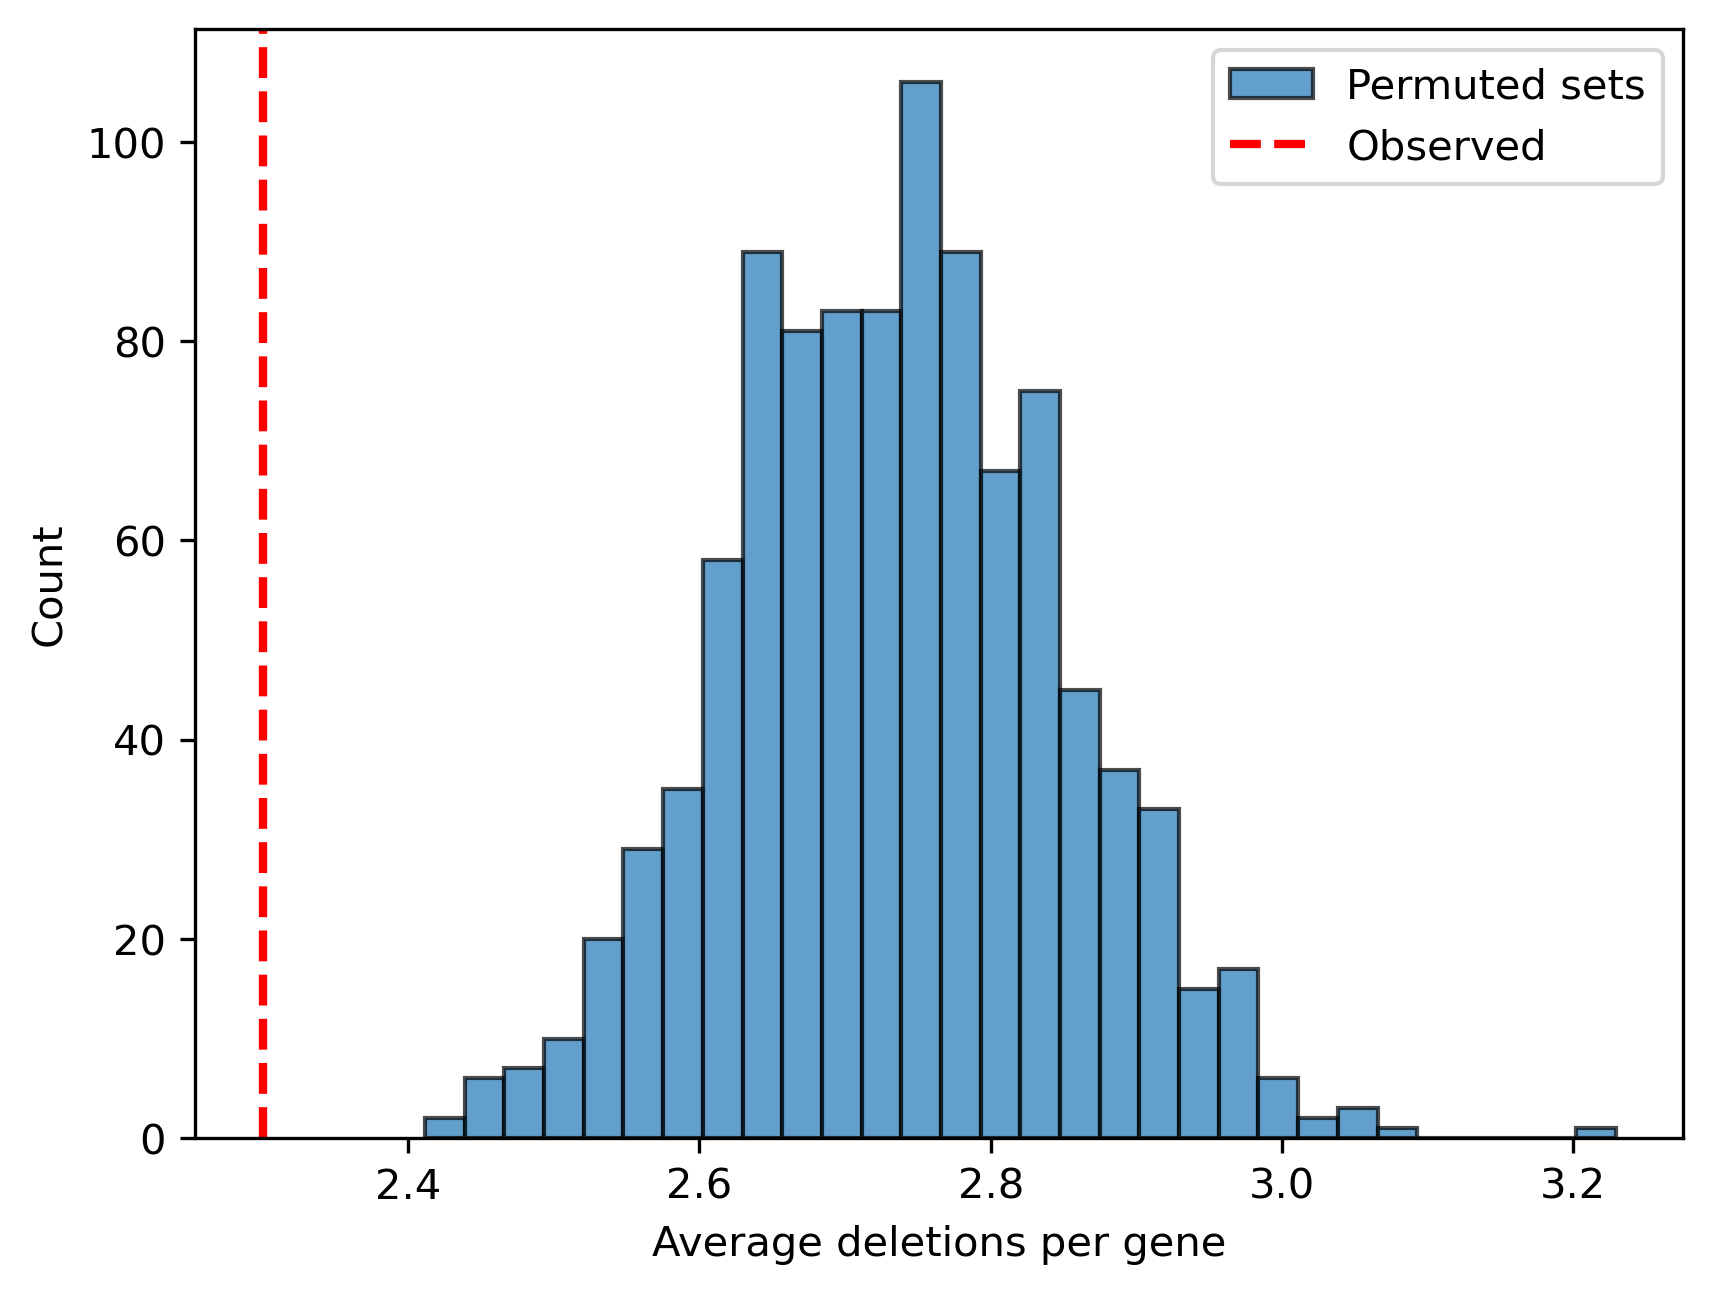

In [11]:
# plot the permutations versus the observed value
plt.hist(avg_deletions_stat.values(), bins=30, edgecolor='black', alpha=0.7, label='Permuted sets')
plt.axvline(avg_deletions_per_dnd_gene, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Average deletions per gene')
plt.ylabel('Count')
plt.legend()
plt.show()

## Now let's compare to randomly sampled disease genes from ClinGen

In [12]:
# load clingen gene-disease data
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols

In [13]:
# filter to moderately confident disease associations
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Moderate', 'Limited', 'Strong'])]
gd

,GENE SYMBOL,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,SOP,CLASSIFICATION,ONLINE REPORT,CLASSIFICATION DATE,GCEP
5,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,SOP10,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2024-03-14T16:00:00.000Z,Charcot-Marie-Tooth Disease Gene Curation Expe...
6,AARS2,HGNC:21022,mitochondrial disease,MONDO:0044970,AR,SOP8,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2022-04-18T16:00:00.000Z,Mitochondrial Diseases Gene Curation Expert Panel
7,ABAT,HGNC:23,developmental and epileptic encephalopathy,MONDO:0100062,AR,SOP8,Moderate,https://search.clinicalgenome.org/kb/gene-vali...,2022-04-19T16:00:00.000Z,Epilepsy Gene Curation Expert Panel
8,ABCA3,HGNC:33,interstitial lung disease due to ABCA3 deficiency,MONDO:0012582,AR,SOP10,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2024-09-17T16:00:00.000Z,Interstitial Lung Disease Gene Curation Expert...
9,ABCA4,HGNC:34,ABCA4-related retinopathy,MONDO:0800406,AR,SOP9,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2022-10-06T16:00:00.000Z,Retina Gene Curation Expert Panel
...,...,...,...,...,...,...,...,...,...,...
3331,NIPBL,HGNC:28862,Cornelia de Lange syndrome,MONDO:0016033,AD,SOP11,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2025-08-11T10:00:00.000Z,Intellectual Disability and Autism Gene Curati...
3332,CP,HGNC:2295,aceruloplasminemia,MONDO:0011426,AR,SOP11,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2025-10-27T04:00:00.000Z,General Inborn Errors of Metabolism Gene Curat...
3333,POFUT1,HGNC:14988,Dowling-Degos disease 2,MONDO:0014130,AD,SOP11,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2025-10-20T17:00:00.000Z,Congenital Disorders of Glycosylation Gene Cur...
3334,RERE,HGNC:9965,complex neurodevelopmental disorder with or wi...,MONDO:0100465,AD,SOP9,Definitive,https://search.clinicalgenome.org/kb/gene-vali...,2023-03-21T11:00:00.000Z,Intellectual Disability and Autism Gene Curati...


In [14]:
# select random samples of 1000 genes
n_perms = 1000
set_size = len(observed_dnd_deletions.gene)
universe_list = list(gd['GENE SYMBOL'].unique())  # convert once, outside loop

# precompute deletion counts per gene once, instead of filtering inside the loop
deletion_counts = dels_expanded.dropna(subset=['Genes']).groupby('Genes').size().to_dict()

gene_sets_of_dnd_size_disease = {}
avg_deletions_stat_disease = {}
rng = random.Random(1000)  # seeded once -> reproducible sequence of draws

counter = 0
while counter < n_perms:
    sampled_genes = rng.sample(universe_list, set_size)
    gene_sets_of_dnd_size_disease[counter] = sampled_genes

    # calculate avg number of deletions in the set
    deletion_num_list_disease = []
    for gene in sampled_genes:
        num_deletions = deletion_counts.get(gene, 0)
        deletion_num_list_disease.append(num_deletions)

    avg_deletions_stat_disease[counter] = sum(deletion_num_list_disease) / set_size

    # progress marker
    if (counter + 1) % 100 == 0:
        print(f"Completed {counter + 1}/{n_perms} permutations")

    counter += 1

Completed 100/1000 permutations
Completed 200/1000 permutations
Completed 300/1000 permutations
Completed 400/1000 permutations
Completed 500/1000 permutations
Completed 600/1000 permutations
Completed 700/1000 permutations
Completed 800/1000 permutations
Completed 900/1000 permutations
Completed 1000/1000 permutations


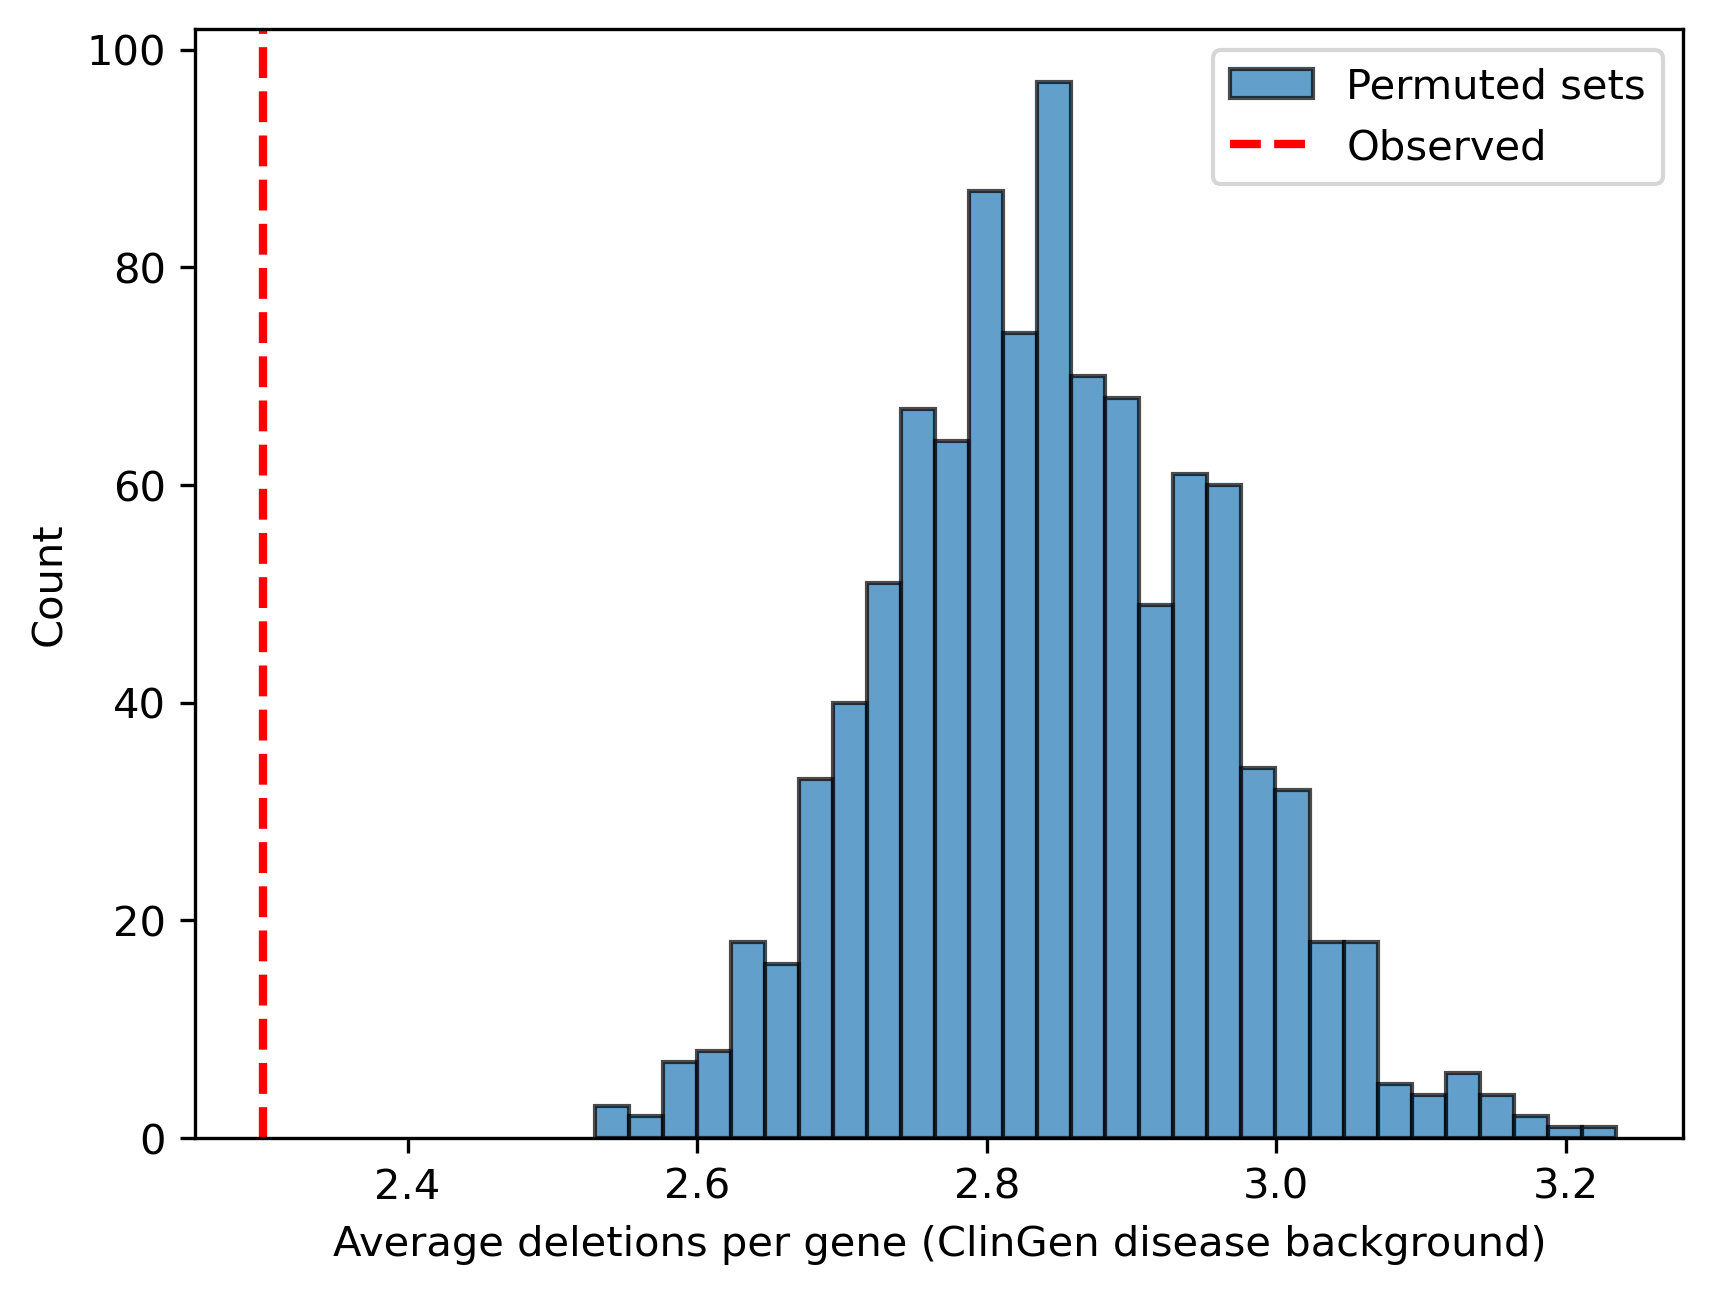

In [15]:
# plot the permutations versus the observed value
plt.hist(avg_deletions_stat_disease.values(), bins=30, edgecolor='black', alpha=0.7, label='Permuted sets')
plt.axvline(avg_deletions_per_dnd_gene, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Average deletions per gene (ClinGen disease background)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [16]:
## what about in comparison to more confident disease gene associations
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Strong'])]

# select random samples of 1000 genes
n_perms = 1000
set_size = len(observed_dnd_deletions.gene)
universe_list = list(gd['GENE SYMBOL'].unique())  # convert once, outside loop

# precompute deletion counts per gene once, instead of filtering inside the loop
deletion_counts = dels_expanded.dropna(subset=['Genes']).groupby('Genes').size().to_dict()

gene_sets_of_dnd_size_strong = {}
avg_deletions_stat_strong = {}
rng = random.Random(1000)  # seeded once -> reproducible sequence of draws

counter = 0
while counter < n_perms:
    sampled_genes = rng.sample(universe_list, set_size)
    gene_sets_of_dnd_size_strong[counter] = sampled_genes

    # calculate avg number of deletions in the set
    deletion_num_list_strong = []
    for gene in sampled_genes:
        num_deletions = deletion_counts.get(gene, 0)
        deletion_num_list_strong.append(num_deletions)

    avg_deletions_stat_strong[counter] = sum(deletion_num_list_strong) / set_size

    # progress marker
    if (counter + 1) % 100 == 0:
        print(f"Completed {counter + 1}/{n_perms} permutations")

    counter += 1

Completed 100/1000 permutations
Completed 200/1000 permutations
Completed 300/1000 permutations
Completed 400/1000 permutations
Completed 500/1000 permutations
Completed 600/1000 permutations
Completed 700/1000 permutations
Completed 800/1000 permutations
Completed 900/1000 permutations
Completed 1000/1000 permutations


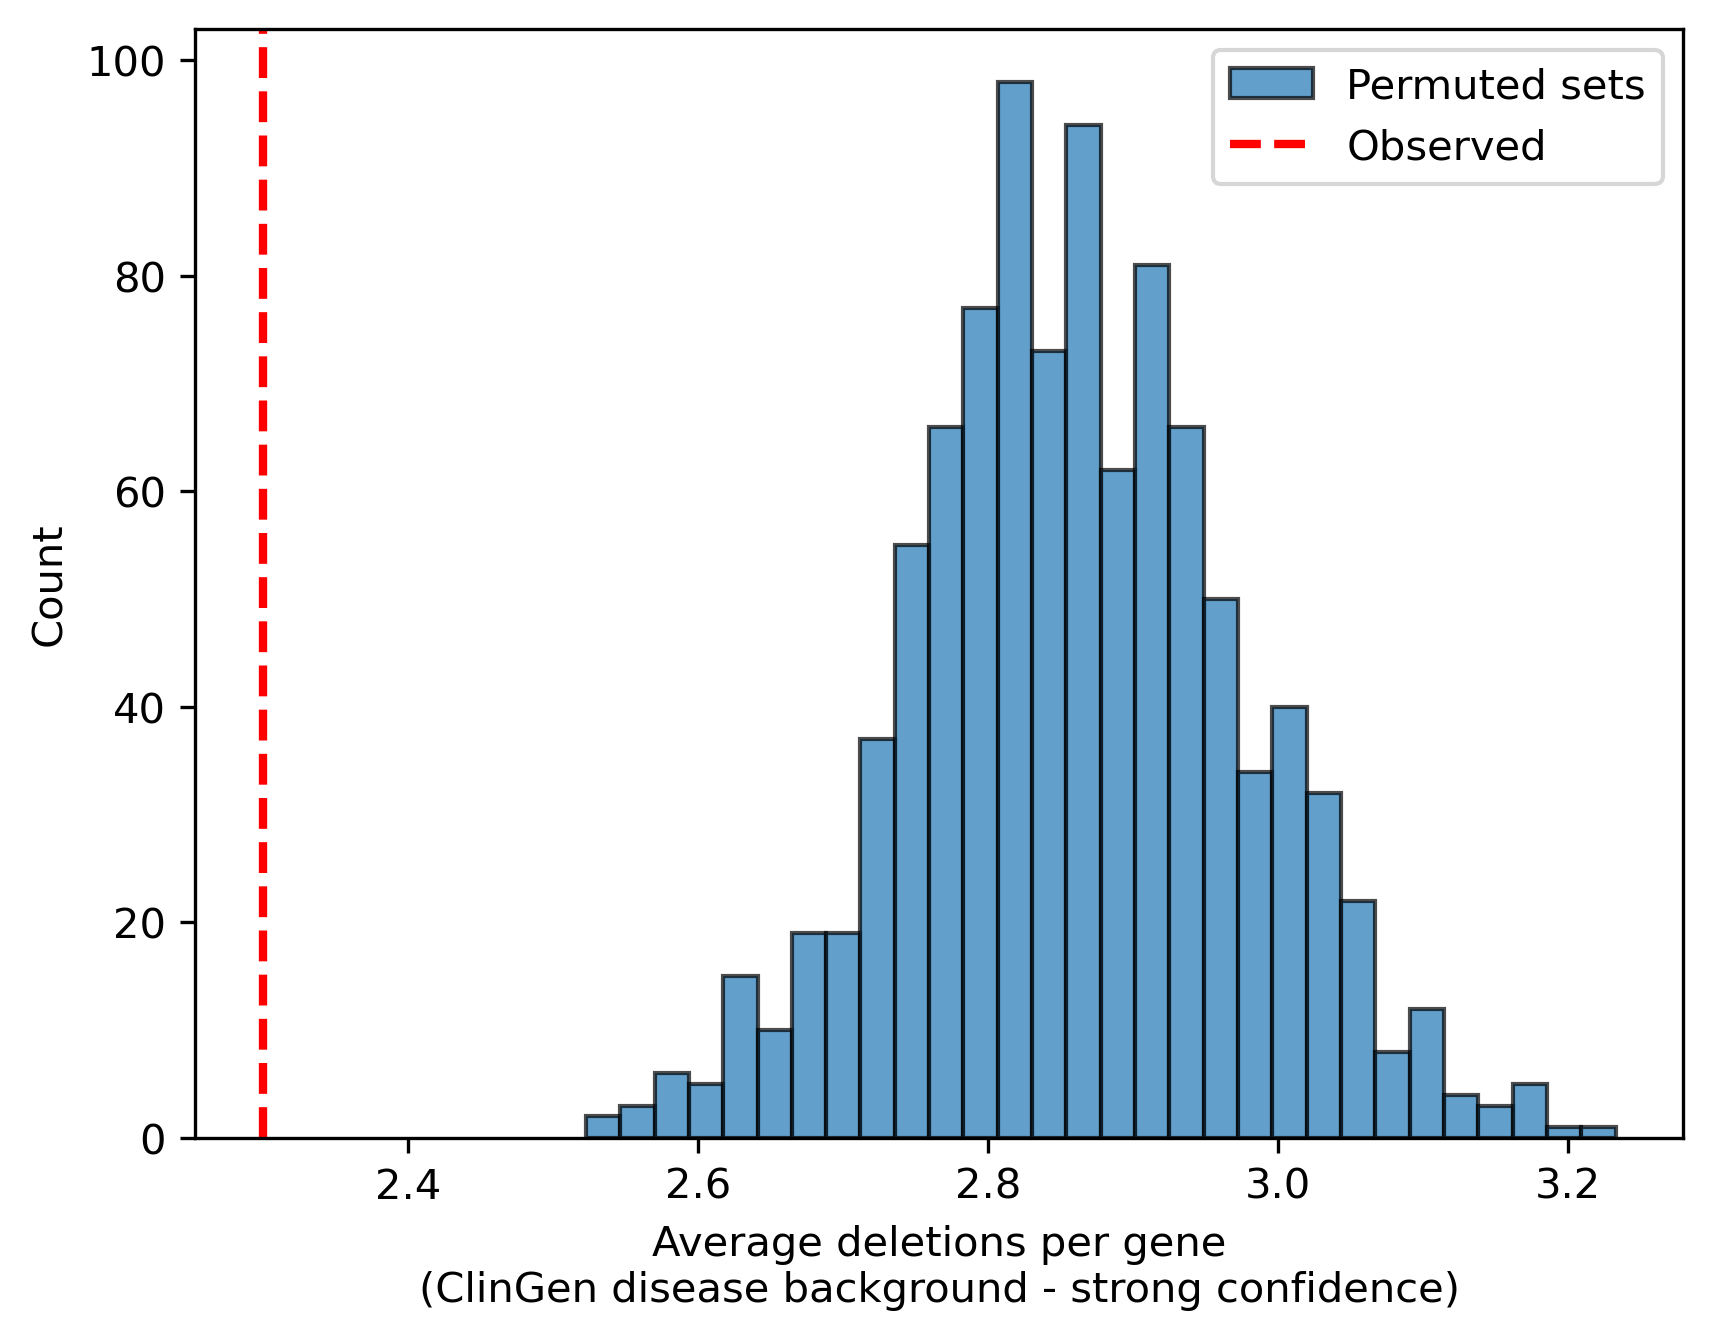

In [17]:
# plot the permutations versus the observed value
plt.hist(avg_deletions_stat_strong.values(), bins=30, edgecolor='black', alpha=0.7, label='Permuted sets')
plt.axvline(avg_deletions_per_dnd_gene, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Average deletions per gene\n(ClinGen disease background - strong confidence)')
plt.ylabel('Count')
plt.legend()
plt.show()

Completed 100/1000 permutations
Completed 200/1000 permutations
Completed 300/1000 permutations
Completed 400/1000 permutations
Completed 500/1000 permutations
Completed 600/1000 permutations
Completed 700/1000 permutations
Completed 800/1000 permutations
Completed 900/1000 permutations
Completed 1000/1000 permutations


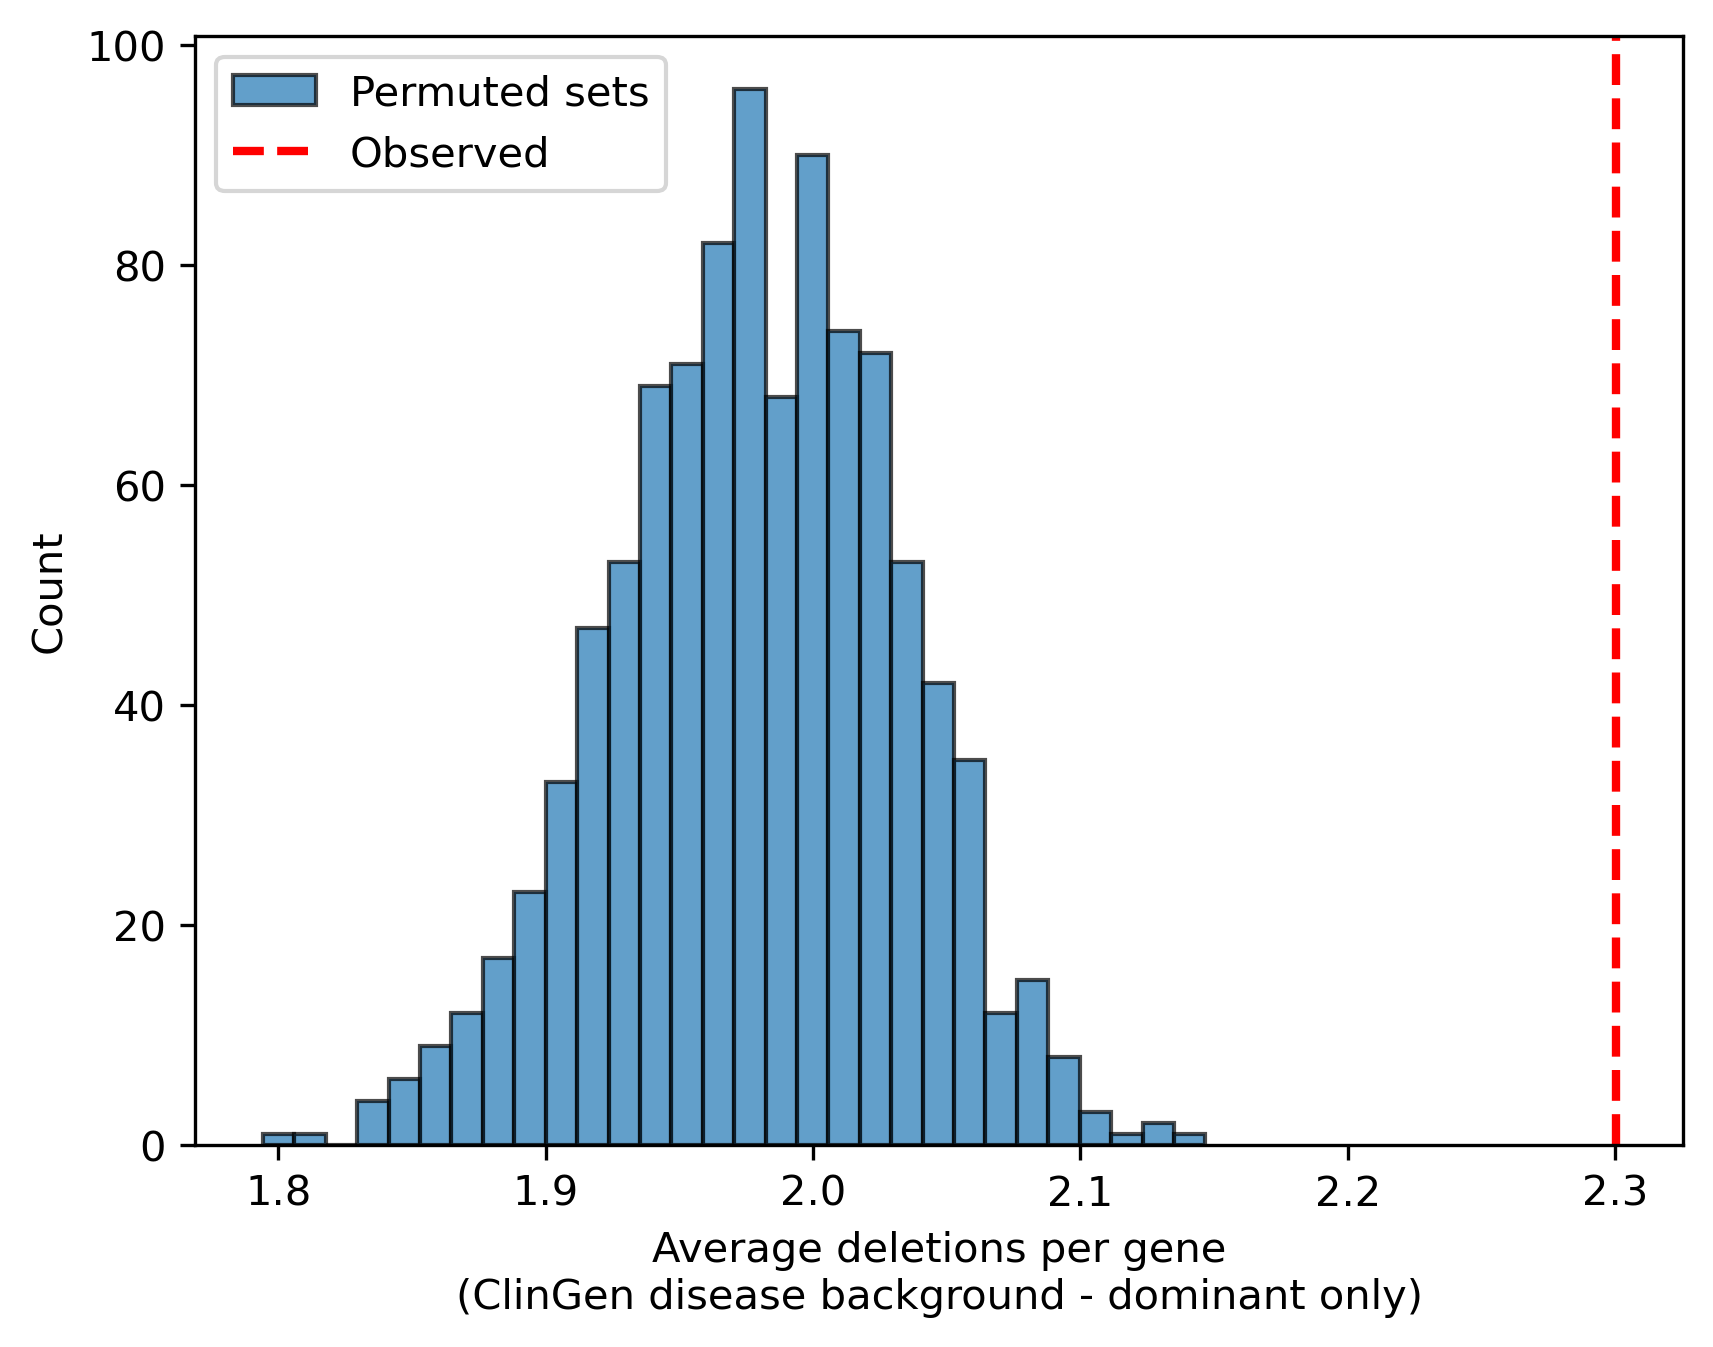

In [18]:
# what about compared to randomly sampled dominant disease genes
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Strong', 'Moderate'])]
gd=gd[gd['MOI'].isin(['AD','SD'])]

# select random samples of 1000 genes
n_perms = 1000
set_size = len(observed_dnd_deletions.gene)
universe_list = list(gd['GENE SYMBOL'].unique())  # convert once, outside loop

# precompute deletion counts per gene once, instead of filtering inside the loop
deletion_counts = dels_expanded.dropna(subset=['Genes']).groupby('Genes').size().to_dict()

gene_sets_of_dnd_size_dom = {}
avg_deletions_stat_dom = {}
rng = random.Random(1000)  # seeded once -> reproducible sequence of draws

counter = 0
while counter < n_perms:
    sampled_genes = rng.sample(universe_list, set_size)
    gene_sets_of_dnd_size_dom[counter] = sampled_genes

    # calculate avg number of deletions in the set
    deletion_num_list_dom = []
    for gene in sampled_genes:
        num_deletions = deletion_counts.get(gene, 0)
        deletion_num_list_dom.append(num_deletions)

    avg_deletions_stat_dom[counter] = sum(deletion_num_list_dom) / set_size

    # progress marker
    if (counter + 1) % 100 == 0:
        print(f"Completed {counter + 1}/{n_perms} permutations")

    counter += 1

# plot
plt.hist(avg_deletions_stat_dom.values(), bins=30, edgecolor='black', alpha=0.7, label='Permuted sets')
plt.axvline(avg_deletions_per_dnd_gene, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Average deletions per gene\n(ClinGen disease background - dominant only)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [19]:
print(len(universe_list))

855


In [20]:
# get a p value for this

perm_values = np.array(list(avg_deletions_stat_dom.values()))
n_perms = len(perm_values)

# Since your hypothesis is that dnd genes have HIGHER avg deletions
# than background (LOF-tolerant genes should show more deletions),
# test for enrichment (one-sided, upper tail):
p_enrichment = (np.sum(perm_values >= avg_deletions_per_dnd_gene) + 1) / (n_perms + 1)

# For completeness, the opposite direction (depletion, lower tail):
p_depletion = (np.sum(perm_values <= avg_deletions_per_dnd_gene) + 1) / (n_perms + 1)

# Two-sided version, if you want to remain agnostic about direction:
p_two_sided = min(p_enrichment, p_depletion) * 2
p_two_sided = min(p_two_sided, 1.0)  # cap at 1

print(f"Observed value: {avg_deletions_per_dnd_gene:.4f}")
print(f"Permutation mean: {perm_values.mean():.4f}, SD: {perm_values.std():.4f}")
print(f"P (enrichment, observed > background): {p_enrichment:.4f}")
print(f"P (depletion, observed < background): {p_depletion:.4f}")
print(f"P (two-sided): {p_two_sided:.4f}")

# Optional: z-score, useful for reporting effect size alongside p-value
z_score = (avg_deletions_per_dnd_gene - perm_values.mean()) / perm_values.std()
print(f"Z-score: {z_score:.4f}")

Observed value: 2.3002
Permutation mean: 1.9788, SD: 0.0536
P (enrichment, observed > background): 0.0010
P (depletion, observed < background): 1.0000
P (two-sided): 0.0020
Z-score: 5.9922


In [21]:
# let's get an effect size too:

# average of permuted distribution
print(f"Permutation distribution average: {np.mean(perm_values)}")
print(f"Observed value: {avg_deletions_per_dnd_gene}")

Permutation distribution average: 1.97877065767285
Observed value: 2.300168634064081


Completed 100/1000 permutations
Completed 200/1000 permutations
Completed 300/1000 permutations
Completed 400/1000 permutations
Completed 500/1000 permutations
Completed 600/1000 permutations
Completed 700/1000 permutations
Completed 800/1000 permutations
Completed 900/1000 permutations
Completed 1000/1000 permutations


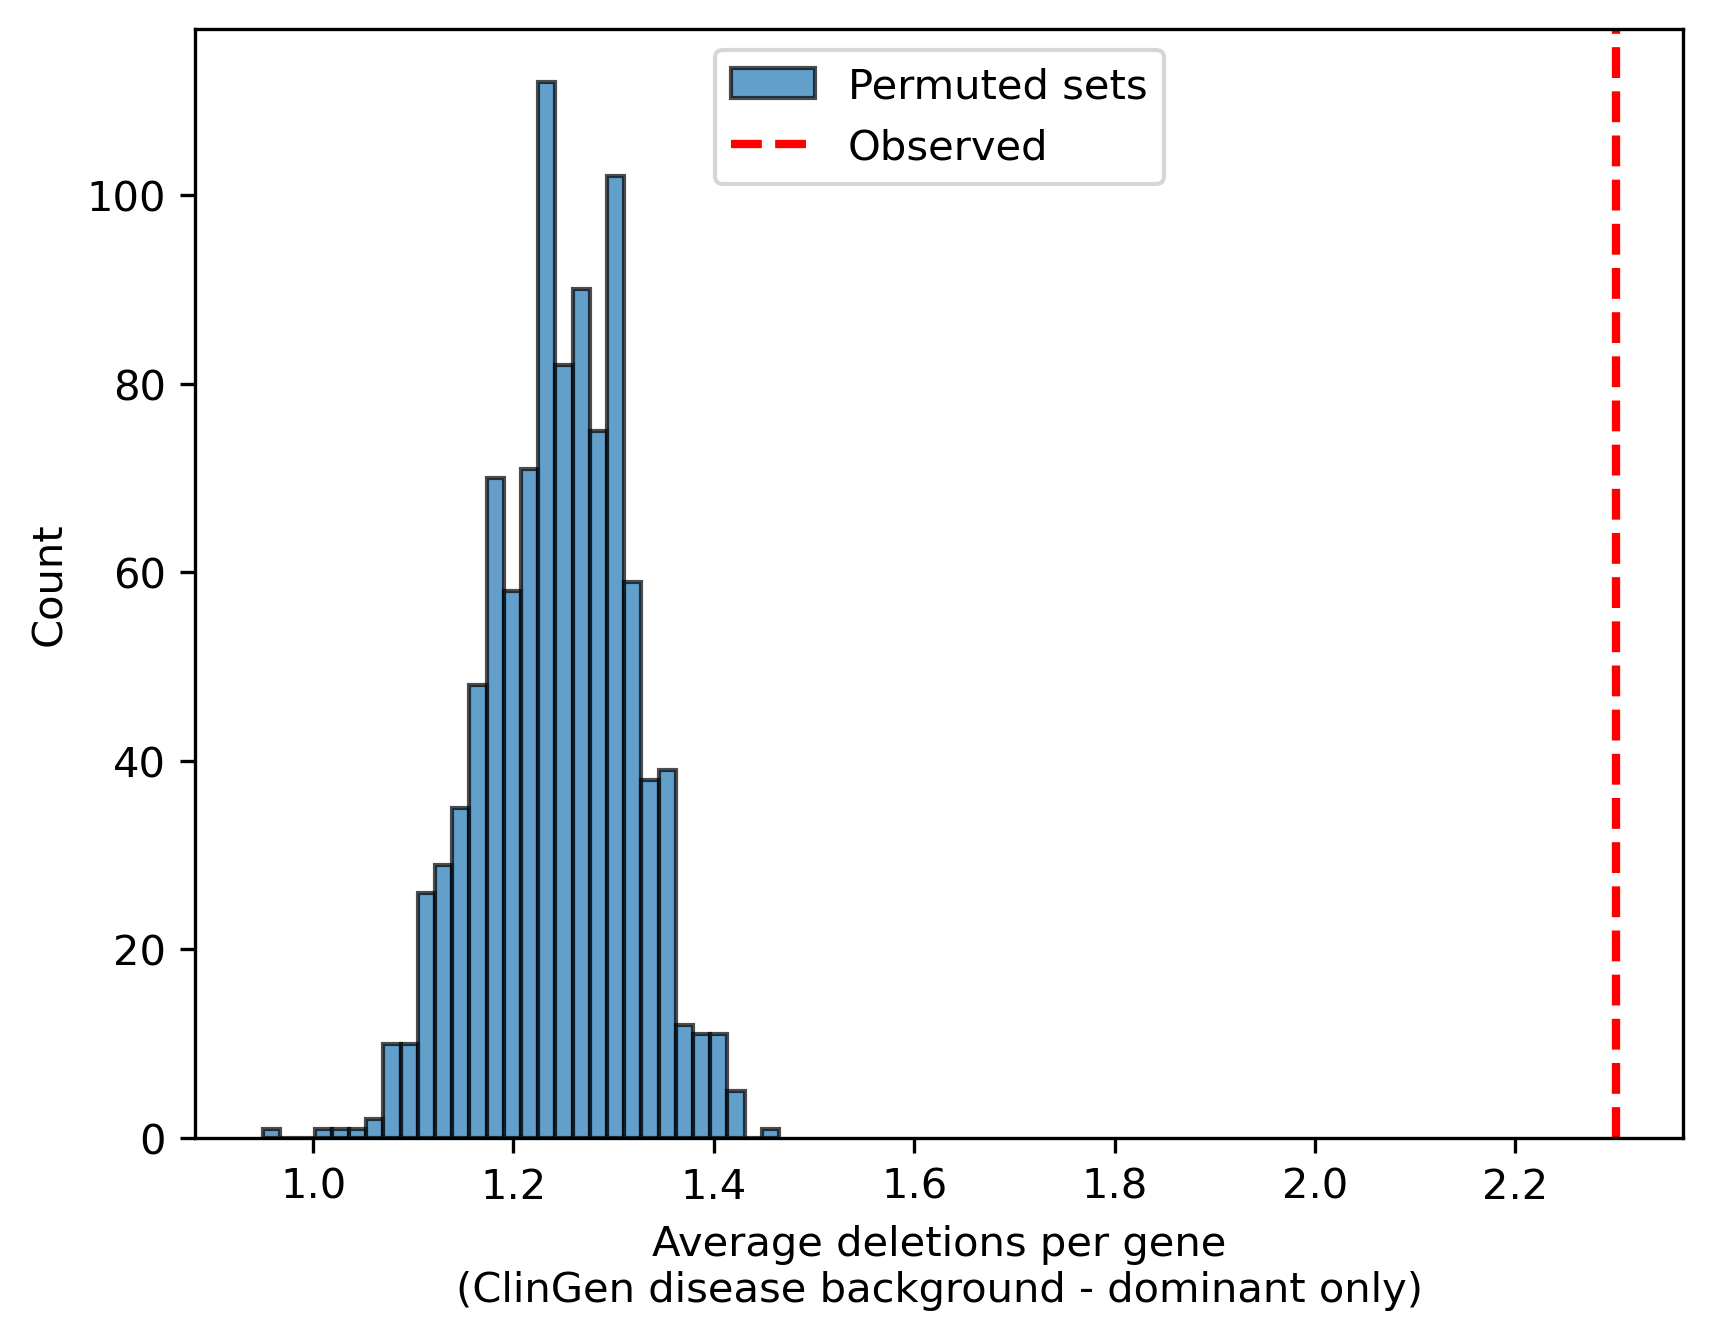

In [22]:
## Finally, let's subtract our dnd_gene set from the clingen dominant disease genes, and recompute
# what about compared to randomly sampled dominant disease genes
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Strong', 'Moderate'])]
gd=gd[gd['MOI'].isin(['AD','SD'])]
gd=gd[~gd['GENE SYMBOL'].isin(observed_dnd_deletions.gene)]

# select random samples of 1000 genes
n_perms = 1000
set_size = len(observed_dnd_deletions.gene)
universe_list = list(gd['GENE SYMBOL'].unique())  # convert once, outside loop

# precompute deletion counts per gene once, instead of filtering inside the loop
deletion_counts = dels_expanded.dropna(subset=['Genes']).groupby('Genes').size().to_dict()

gene_sets_of_dnd_size_sub = {}
avg_deletions_stat_sub = {}
rng = random.Random(1000)  # seeded once -> reproducible sequence of draws
if len(universe_list)<set_size:
    set_size=200

counter = 0
while counter < n_perms:
    sampled_genes = rng.sample(universe_list, set_size)
    gene_sets_of_dnd_size_sub[counter] = sampled_genes

    # calculate avg number of deletions in the set
    deletion_num_list_sub = []
    for gene in sampled_genes:
        num_deletions = deletion_counts.get(gene, 0)
        deletion_num_list_sub.append(num_deletions)

    avg_deletions_stat_sub[counter] = sum(deletion_num_list_sub) / set_size

    # progress marker
    if (counter + 1) % 100 == 0:
        print(f"Completed {counter + 1}/{n_perms} permutations")

    counter += 1

# plot
plt.hist(avg_deletions_stat_sub.values(), bins=30, edgecolor='black', alpha=0.7, label='Permuted sets')
plt.axvline(avg_deletions_per_dnd_gene, color='red', linestyle='--', linewidth=2, label='Observed')
plt.xlabel('Average deletions per gene\n(ClinGen disease background - dominant only)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [23]:
# get a p value for this

perm_values = np.array(list(avg_deletions_stat_sub.values()))
n_perms = len(perm_values)

# Since your hypothesis is that dnd genes have HIGHER avg deletions
# than background (LOF-tolerant genes should show more deletions),
# test for enrichment (one-sided, upper tail):
p_enrichment = (np.sum(perm_values >= avg_deletions_per_dnd_gene) + 1) / (n_perms + 1)

# For completeness, the opposite direction (depletion, lower tail):
p_depletion = (np.sum(perm_values <= avg_deletions_per_dnd_gene) + 1) / (n_perms + 1)

# Two-sided version, if you want to remain agnostic about direction:
p_two_sided = min(p_enrichment, p_depletion) * 2
p_two_sided = min(p_two_sided, 1.0)  # cap at 1

print(f"Observed value: {avg_deletions_per_dnd_gene:.4f}")
print(f"Permutation mean: {perm_values.mean():.4f}, SD: {perm_values.std():.4f}")
print(f"P (enrichment, observed > background): {p_enrichment:.4f}")
print(f"P (depletion, observed < background): {p_depletion:.4f}")
print(f"P (two-sided): {p_two_sided:.4f}")

# Optional: z-score, useful for reporting effect size alongside p-value
z_score = (avg_deletions_per_dnd_gene - perm_values.mean()) / perm_values.std()
print(f"Z-score: {z_score:.4f}")

# average of permuted distribution
print(f"Permutation distribution average: {np.mean(perm_values)}")
print(f"Observed value: {avg_deletions_per_dnd_gene}")

Observed value: 2.3002
Permutation mean: 1.2454, SD: 0.0720
P (enrichment, observed > background): 0.0010
P (depletion, observed < background): 1.0000
P (two-sided): 0.0020
Z-score: 14.6501
Permutation distribution average: 1.245375
Observed value: 2.300168634064081


## This is how the dom_minus_dnd was calculated here

In [34]:
# let's get the actual distribution in the dominant (minus D&D genes) set
# what about compared to randomly sampled dominant disease genes
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Strong', 'Moderate'])]
gd=gd[gd['MOI'].isin(['AD','SD'])]
gd=gd[~gd['GENE SYMBOL'].isin(set(observed_dnd_deletions.gene))]

# precompute deletion counts per gene once, instead of filtering inside the loop
deletion_counts = dels_expanded.dropna(subset=['Genes']).groupby('Genes').size().to_dict()
# calculate avg number of deletions in the set
genes = gd['GENE SYMBOL'].unique()

background_deletions = pd.DataFrame({
    'gene': genes,
    'num_deletions': [deletion_counts.get(g, 0) for g in genes]
})

In [35]:
print(len(observed_dnd_deletions.gene))
observed_dnd_deletions

593


,gene,num_deletions
0,TGFBR2,1
1,ATXN2,1
2,HNRNPDL,0
3,SMARCC1,1
4,STX1B,0
...,...,...
588,HRG,4
589,P2RY12,1
590,EED,0
591,SLC30A2,3


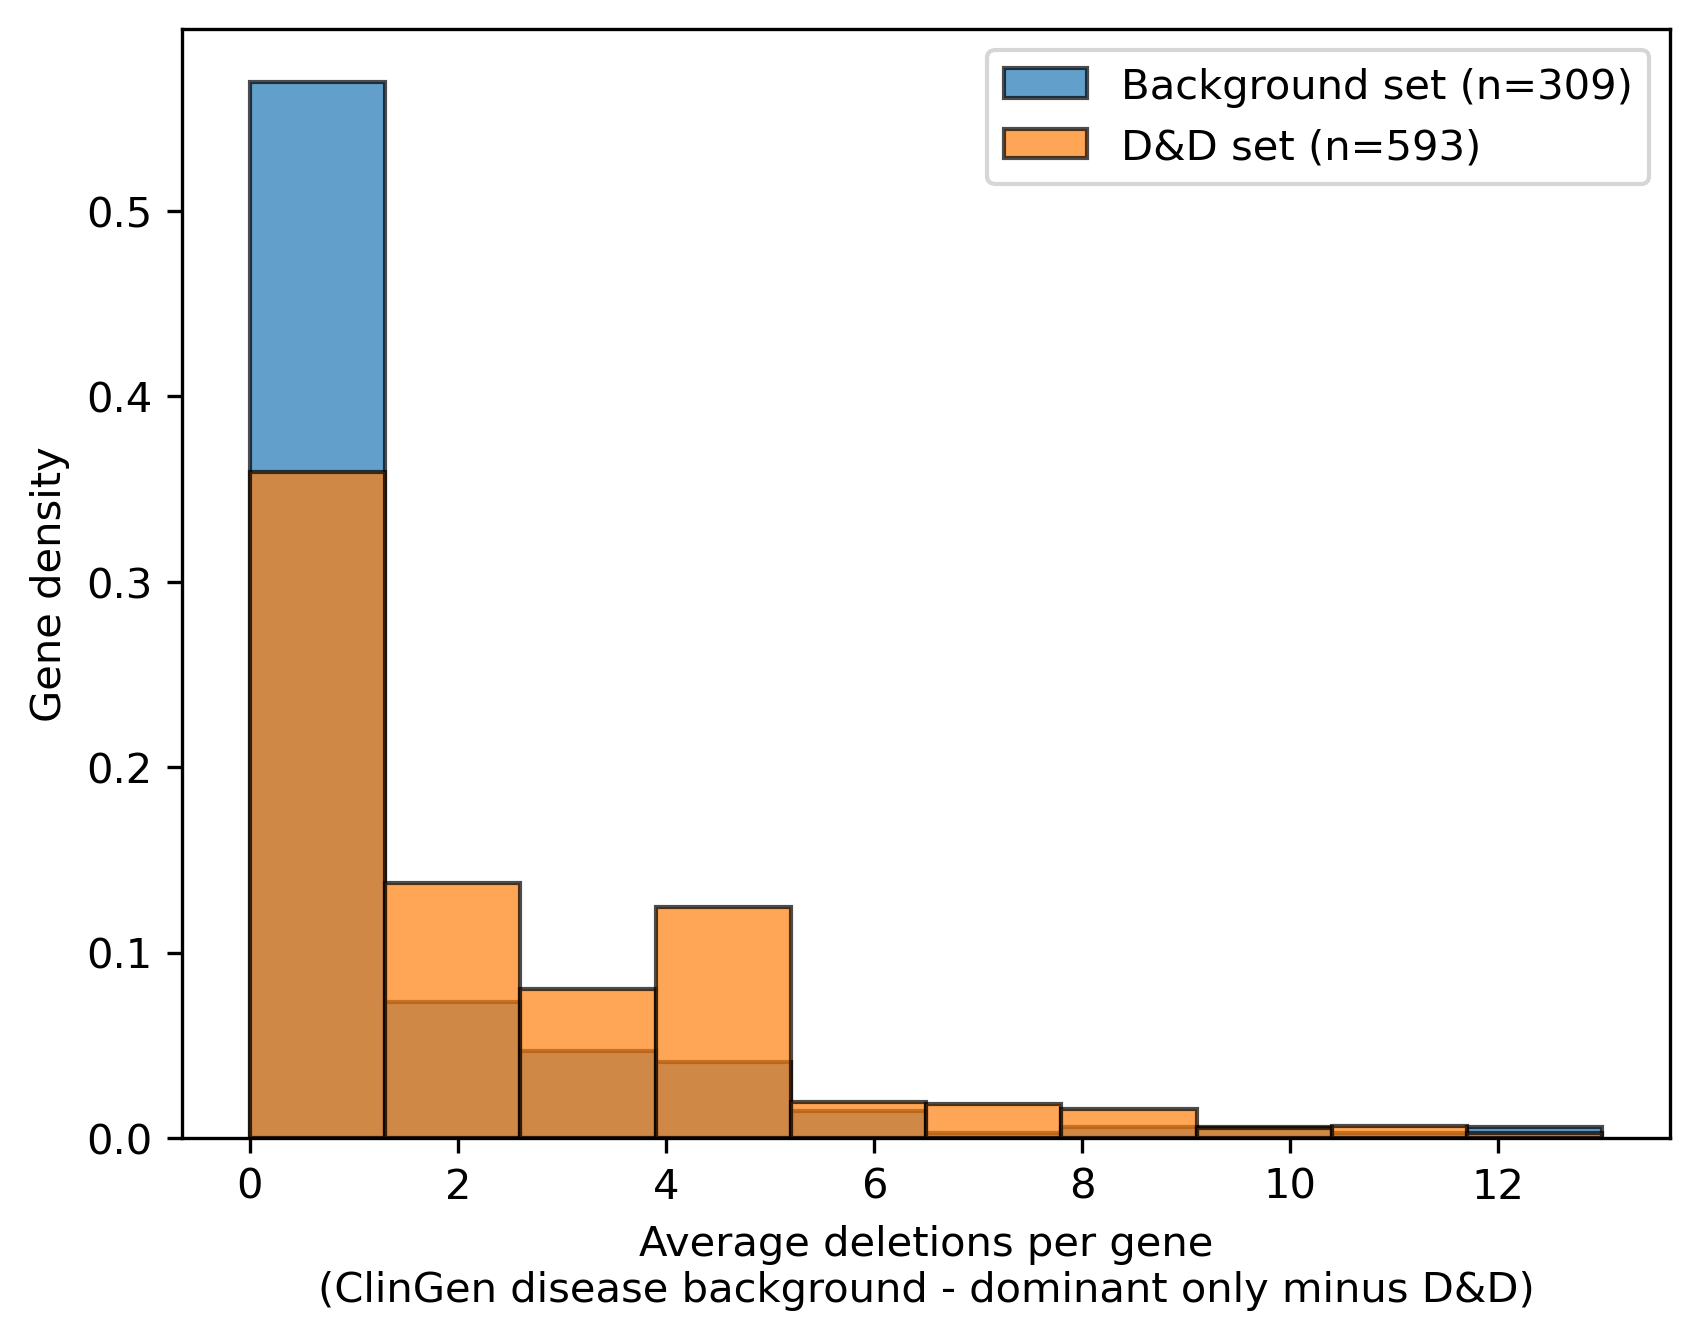

In [36]:
# plot
plt.hist(background_deletions['num_deletions'].values, density=True, edgecolor='black', alpha=0.7, label='Background set (n=309)')
plt.hist(observed_dnd_deletions['num_deletions'].values, density=True, edgecolor='black',alpha=0.7, label='D&D set (n=593)')
plt.xlabel('Average deletions per gene\n(ClinGen disease background - dominant only minus D&D)')
plt.ylabel('Gene density')
plt.legend()
plt.show()

/scratch/gramey02/ipykernel_3074375/3930632364.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


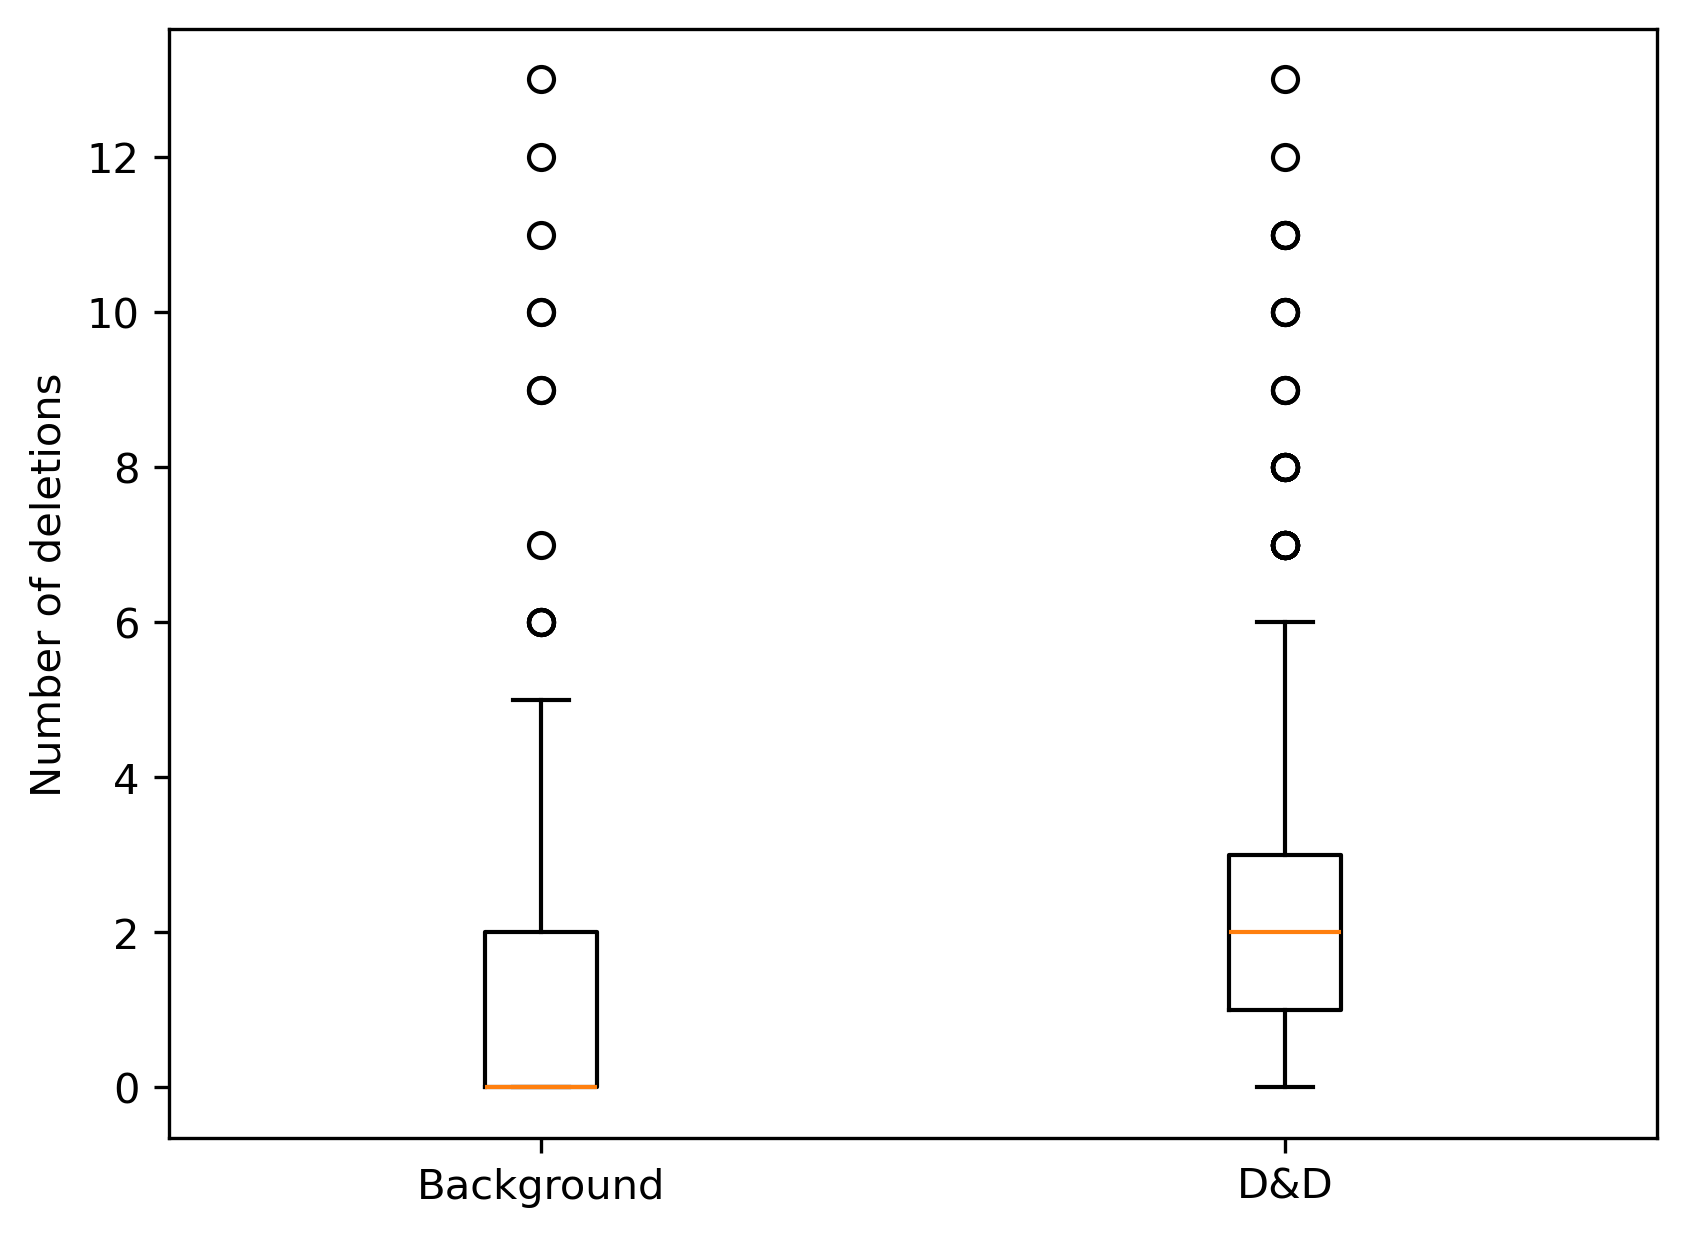

In [37]:
# look in barplot form
plt.boxplot(
    [
        background_deletions['num_deletions'],
        observed_dnd_deletions['num_deletions']
    ],
    labels=['Background', 'D&D']
)
plt.ylabel('Number of deletions')
plt.show()

In [38]:
# compute statistics
from scipy.stats import mannwhitneyu

background = background_deletions['num_deletions'].values
dnd = observed_dnd_deletions['num_deletions'].values

stat, p = mannwhitneyu(
    background,
    dnd,
    alternative='less'
)

print(f"U statistic: {stat}")
print(f"p-value: {p}")

U statistic: 51442.5
p-value: 2.8939395973538946e-16


In [42]:
observed_dnd_deletions

,gene,num_deletions
0,TGFBR2,1
1,ATXN2,1
2,HNRNPDL,0
3,SMARCC1,1
4,STX1B,0
...,...,...
588,HRG,4
589,P2RY12,1
590,EED,0
591,SLC30A2,3


In [40]:
background_deletions

,gene,num_deletions
0,AHDC1,0
1,ANKRD11,1
2,APC,3
3,APOB,1
4,ARID1A,0
...,...,...
257,HNRNPU,1
258,CNOT1,0
259,MYT1L,0
260,SYNCRIP,0


In [45]:
# get recessive counts
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Strong'])]
gd=gd[gd['MOI'].isin(['AR'])]
# remove the dnd genes
gd=gd[~gd['GENE SYMBOL'].isin(set(observed_dnd_deletions.gene))]
recessive_genes = gd[['GENE SYMBOL']].drop_duplicates()

# get counts of deletions for each recessive gene

# precompute deletion counts per gene once, instead of filtering inside the loop
deletion_counts = dels_expanded.dropna(subset=['Genes']).groupby('Genes').size().to_dict()
# calculate avg number of deletions in the set
genes = recessive_genes['GENE SYMBOL'].unique()

recessive_deletions_df = pd.DataFrame({
    'gene': genes,
    'num_deletions': [deletion_counts.get(g, 0) for g in genes]
})

In [46]:
recessive_deletions_df

,gene,num_deletions
0,AARS2,6
1,ABCA3,5
2,ABCA4,3
3,ABCB4,4
4,ABCG5,8
...,...,...
1054,PGAP3,1
1055,ITCH,2
1056,IFT74,13
1057,CP,5


In [58]:
# compute stats
from itertools import combinations
from scipy.stats import mannwhitneyu

comparison_groups = [dnd_deletions, g2_deletions, dom_deletions, recessive_deletions]
group_names = ['D&D Group 1', 'D&D Group 2', 'ClinGen dominant, D&D removed', 'ClinGen recessive only']

results = []

for (name1, combo1), (name2, combo2) in combinations(zip(group_names, comparison_groups), 2):
    stat, p = mannwhitneyu(
        combo1,
        combo2,
        alternative='two-sided'
    )
    results.append({
        'group1': name1,
        'group2': name2,
        'U_statistic': stat,
        'p_value': p
    })

results_df = pd.DataFrame(results)
results_df['p_adj_fdr_bh'] = multipletests(results_df['p_value'], method='fdr_bh')[1]
results_df

,group1,group2,U_statistic,p_value,p_adj_fdr_bh
0,D&D Group 1,D&D Group 2,91812.5,1.078262e-04,1.078262e-04
1,D&D Group 1,"ClinGen dominant, D&D removed",103923.5,5.787879e-16,8.681819e-16
2,D&D Group 1,ClinGen recessive only,217806.5,1.759419e-25,5.278256e-25
3,D&D Group 2,"ClinGen dominant, D&D removed",69661.0,3.254206e-24,6.508411e-24
4,D&D Group 2,ClinGen recessive only,159048.5,7.510159e-07,9.012191e-07
5,"ClinGen dominant, D&D removed",ClinGen recessive only,59003.5,5.656932e-48,3.394159e-47


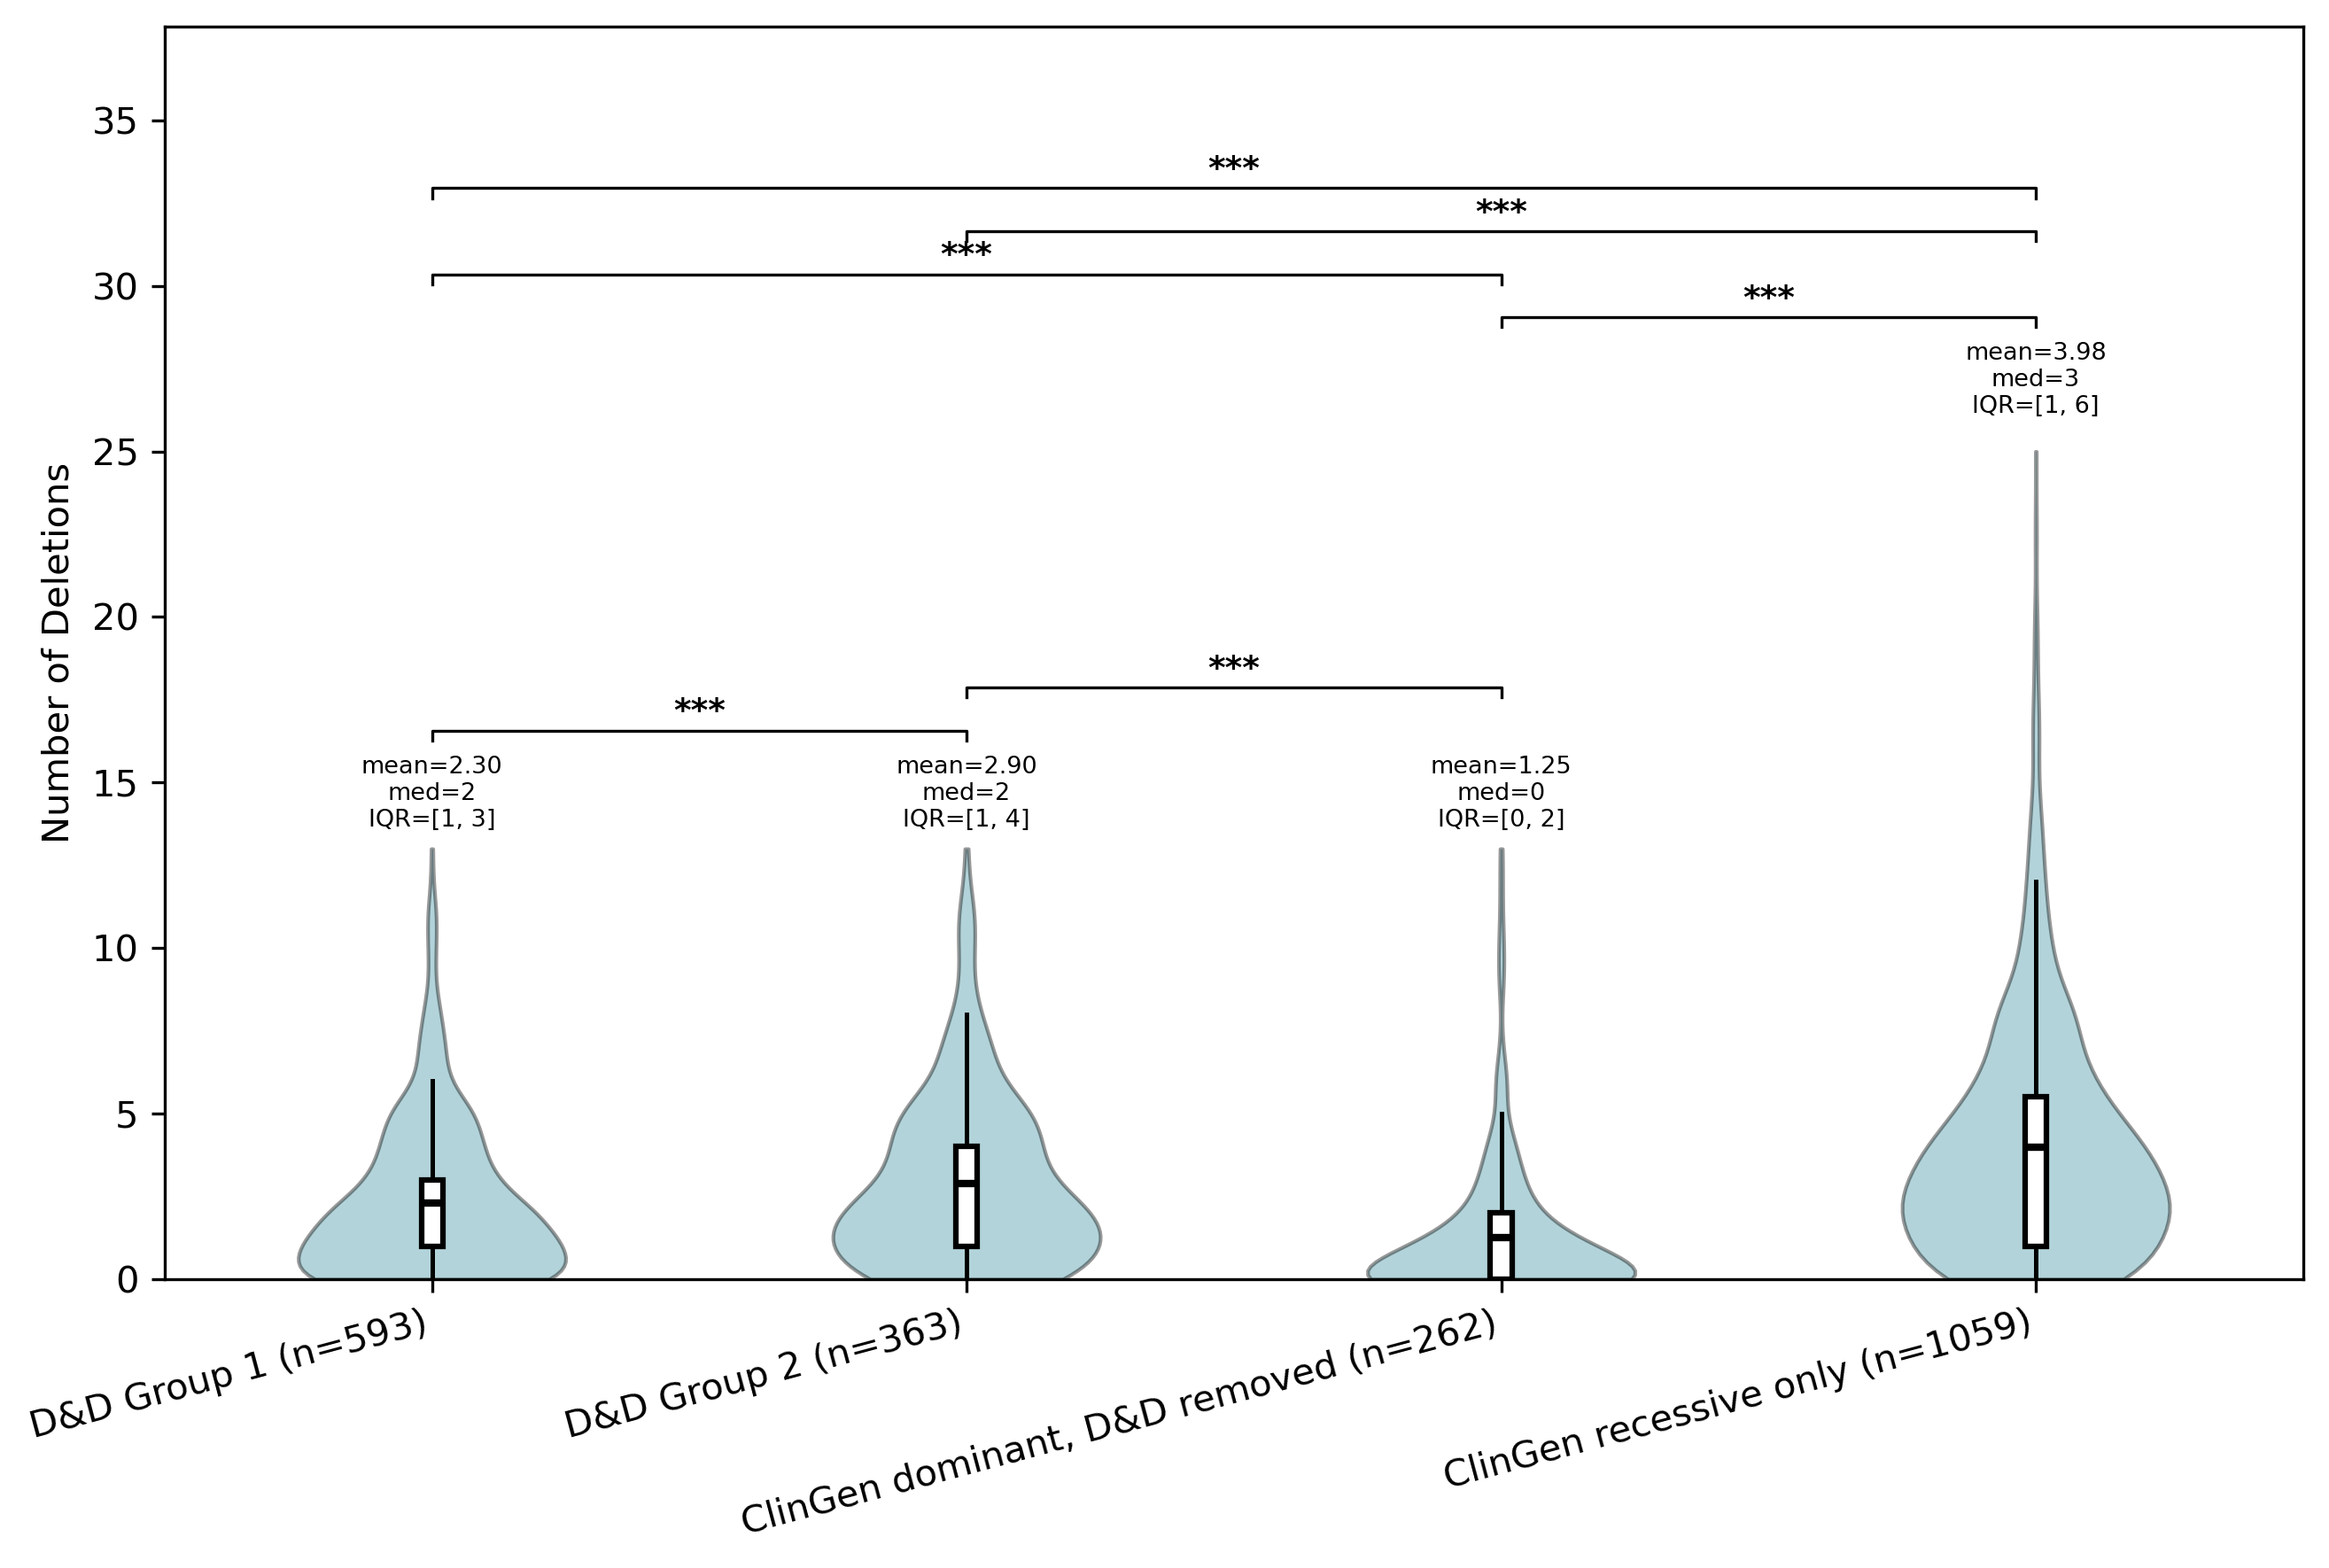

In [57]:
## Now let's plot things as a violin plot
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# --- Data setup ---
dnd_deletions = observed_dnd_deletions['num_deletions'].values
dom_deletions = background_deletions['num_deletions'].values
recessive_deletions = recessive_deletions_df['num_deletions'].values
master_df = pd.read_csv('/wynton/home/capra/gramey02/dnd_project/results/RUN_MULTIALLELIC/summary_files/cleaned_master_df_2026_08_25.csv')
g2_genes = set(master_df[master_df['Gene_Group']=='Group 2']['hgnc_symbol'].unique())
g2_dnd = observed_dnd_deletions[observed_dnd_deletions['gene'].isin(g2_genes)]
g2_deletions = g2_dnd['num_deletions'].values

v_data = [dnd_deletions, g2_deletions, dom_deletions, recessive_deletions]
group_names = ['D&D Group 1', 'D&D Group 2', 'ClinGen dominant, D&D removed', 'ClinGen recessive only']
labels = [f'{name} (n={len(arr)})' for name, arr in zip(group_names, v_data)]

v_data_log = v_data.copy()

# --- Mann-Whitney U tests across all group pairs ---
results = []
for (name1, combo1), (name2, combo2) in combinations(zip(group_names, v_data), 2):
    stat, p = mannwhitneyu(combo1, combo2, alternative='two-sided')
    results.append({'group1': name1, 'group2': name2, 'U_statistic': stat, 'p_value': p})

results_df = pd.DataFrame(results)
results_df['p_adj_fdr_bh'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

alpha = 0.05
sig_results = results_df[results_df['p_adj_fdr_bh'] < alpha].copy()

def p_to_asterisks(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

parts = ax.violinplot(v_data_log, showmedians=False, showextrema=False)
violin_color = '#4092A0'
for body in parts['bodies']:
    body.set_facecolor(violin_color)
    body.set_edgecolor('black')
    body.set_alpha(0.4)

bp = ax.boxplot(
    v_data_log,
    widths=0.04,
    patch_artist=True,
    showfliers=False,
    whis=1.5,
    showmeans=True,
    meanline=True,
    medianprops=dict(linewidth=0, color='none'),
    meanprops=dict(color='black', linewidth=2, linestyle='-')
)
for box in bp['boxes']:
    box.set_facecolor('white')
    box.set_edgecolor('black')
    box.set_linewidth(1.5)
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(1.2)
for cap in bp['caps']:
    cap.set_visible(False)
for median in bp['medians']:
    median.set_visible(False)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel("Number of Deletions")

data_max = max(arr.max() for arr in v_data)

# --- Mean/median/IQR text, positioned above each violin's own max ---
for i, arr in enumerate(v_data, start=1):
    mean_val = np.mean(arr)
    median_val = np.median(arr)
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    local_max = arr.max()
    text_y = local_max * 1.04  # tighter padding above the violin's tallest point
    ax.text(
        i, text_y,
        f"mean={mean_val:.2f}\nmed={median_val:.0f}\nIQR=[{q1:.0f}, {q3:.0f}]",
        ha='center', va='bottom', fontsize=6.5
    )

# --- Significance brackets + asterisks: dynamically positioned to hug their own pair ---
group_to_xpos = {name: i+1 for i, name in enumerate(group_names)}

text_block_height = data_max * 0.09
text_heights = {i+1: arr.max() * 1.04 + text_block_height for i, arr in enumerate(v_data)}

sig_results_sorted = sig_results.copy()
sig_results_sorted['x1'] = sig_results_sorted['group1'].map(group_to_xpos)
sig_results_sorted['x2'] = sig_results_sorted['group2'].map(group_to_xpos)
sig_results_sorted['span'] = (sig_results_sorted['x2'] - sig_results_sorted['x1']).abs()
sig_results_sorted = sig_results_sorted.sort_values('span').reset_index(drop=True)

# Optional manual overrides: key = (group1_name, group2_name), value = y position to force
manual_y_overrides = {
    # example: ('D&D Group 1', 'ClinGen dominant, D&D removed'): 22,
}

placed_brackets = []
bracket_gap = data_max * 0.02      # tightened from 0.045
tick_height = data_max * 0.012     # tightened from 0.015
label_height = data_max * 0.02     # tightened from 0.035

for row in sig_results_sorted.itertuples():
    x1, x2 = min(row.x1, row.x2), max(row.x1, row.x2)

    override_key = (row.group1, row.group2)
    override_key_rev = (row.group2, row.group1)

    if override_key in manual_y_overrides:
        y = manual_y_overrides[override_key]
    elif override_key_rev in manual_y_overrides:
        y = manual_y_overrides[override_key_rev]
    else:
        min_y = max(text_heights[x] for x in range(x1, x2 + 1)) + bracket_gap
        for (px1, px2, p_top) in placed_brackets:
            if x1 <= px2 and x2 >= px1:
                min_y = max(min_y, p_top + bracket_gap)
        y = min_y

    top_of_label = y + tick_height + label_height
    placed_brackets.append((x1, x2, top_of_label))

    ax.plot([x1, x1, x2, x2], [y, y + tick_height, y + tick_height, y],
            color='black', linewidth=0.8)
    stars = p_to_asterisks(row.p_adj_fdr_bh)
    ax.text((x1 + x2) / 2, y + tick_height * 1.2, stars,
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ax.text(0.02, 0.98, "*p<0.05  **p<0.01  ***p<0.001", 
#          transform=ax.transAxes, fontsize=7, va='top', ha='left')

# --- y-axis headroom based on the tallest bracket actually placed ---
top_y = max(y for (_, _, y) in placed_brackets) + tick_height * 3
ax.set_ylim(bottom=0, top=top_y)

# --- Reduced headroom on y-axis top ---
ax.set_ylim(bottom=0, top=bracket_base_y + max(len(sig_results), 1) * bracket_step + bracket_step*0.5)

plt.tight_layout()
plt.savefig("/wynton/home/capra/gramey02/dnd_project/data/figs/deletion_distribution.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()

## Okay, that makes more sense!
Now, in a separate notebook, let's check on benign variant enrichments in gnomAD.